# 08 — Feature Selection for CBS Absenteeism Forecasting

## Workflow

```
Phase  Step  Description
─────  ────  ──────────────────────────────────────────────────────────────
  1      1   Load gold dataset & column audit
         2   Identify feature columns (exclude structural + OHE + target)
         3   Near-constant pre-filter (remove broken features)

  2      4   Independent signal detection — four toggleable filters:
              4A  Contemporaneous correlation (within-sector differenced)
              4B  Lagged correlation (forecast-aligned, h=1,2,3)
              4C  Granger causality (per-sector, differenced)
              4D  Lasso stability selection (forecast-aligned bootstraps)

  3      5   Consensus voting (keep features passing ≥ K of active filters)
         6   Scatter validation (visual sanity check on top survivors)
         7   Redundancy removal (hierarchical clustering on consensus set)
         8   Feature group assignment & JSON export

  App.   9   Per-sector feature relevance diagnostic
```

### Architecture: independent evaluation + voting

Each Phase 2 filter evaluates **all** Phase 1 survivors independently — no filter's
output constrains another's input. The final selection is based on **multi-method
agreement**, not sequential cascading. This avoids the fundamental cascade flaw where
a feature killed early is never tested by later methods.

### Toggle system

Each filter in Phase 2 has a configuration knob:

| Variable | Values | Effect |
|---|---|---|
| `APPLY_<FILTER>` | `True` / `False` | Include this filter in the consensus vote |

Set `APPLY_*` = `False` to exclude a filter from voting without deleting its cell.
The filter still runs (so you can inspect its scores), but its pass/fail result
won't count toward the vote total.

---
## 1 — Setup & Data Loading

In [ ]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Project path (walks up until it finds src/) ──────────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    DIR_DB_GOLD, DIR_FEATURE_SELECTION, ML_TARGET_COLUMN,
    C_GREY, C_BLUE, C_ORANGE, C_GRID, C_TEXT,
)
from src.ml_engineering.ml_1_data_extraction import DataExtractor
from src.utils.feature_selection_utils import (
    STRUCTURAL_COLS, SECTOR_COL, TIME_COL, SBI_FILTER_PREFIX,
    SOURCE_TABLE_LOOKUP, MERGE_MAP,
    identify_feature_columns,
    apply_near_constant_filter,
    apply_redundancy_filter,
    apply_correlation_filter,
    apply_tree_filter,              # not in main pipeline; available for experimentation
    apply_lagged_correlation_filter,
    apply_granger_filter,
    apply_lasso_stability_filter,
    apply_domain_prefix_filter,     # not in main pipeline; available for experimentation
    build_proposed_groups,
    validate_feature_groups,
    save_preset_to_json,
)

# ── Suppress noisy library warnings ─────────────────────────────────────
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Visual style (project-consistent) ───────────────────────────────────
RETAINED_COLOR = C_BLUE
DROPPED_COLOR  = C_GREY
ACCENT_COLOR   = C_ORANGE

plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.edgecolor":     C_GREY,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "axes.axisbelow":     True,
    "grid.color":         C_GRID,
    "grid.linewidth":     0.5,
    "grid.alpha":         0.8,
    "xtick.color":        C_GREY,
    "ytick.color":        C_GREY,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "axes.labelcolor":    C_GREY,
    "axes.titlesize":     11,
    "axes.titleweight":   "regular",
    "axes.titlecolor":    C_TEXT,
    "axes.titlelocation": "left",
    "axes.titlepad":      10,
    "font.family":        "sans-serif",
    "legend.frameon":     False,
    "legend.fontsize":    9,
    "figure.dpi":         110,
})


def _legend_handles():
    """Standard Retained / Dropped legend patches used by every filter plot."""
    return [
        mpatches.Patch(facecolor=RETAINED_COLOR, edgecolor="white", label="Retained"),
        mpatches.Patch(facecolor=DROPPED_COLOR,  edgecolor="white", label="Dropped"),
    ]


TARGET = ML_TARGET_COLUMN
print(f"Project root : {PROJECT_ROOT}")
print(f"Target       : {TARGET}")

Project root : c:\Git\eaisi-uwv
Target       : Ziekteverzuimpercentage_1


In [ ]:
# ── Load gold panel dataset ──────────────────────────────────────────────
df = DataExtractor.load_full_panel(
    db_path=DIR_DB_GOLD, table_name="master_data_ml_preprocessed",
)

n_sectors = df[SECTOR_COL].nunique()
n_quarters = df[TIME_COL].nunique()
print(f"Shape:       {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Sectors:     {n_sectors}")
print(f"Quarters:    {n_quarters}")
print(f"Date range:  {df[TIME_COL].min()} → {df[TIME_COL].max()}")

✅ Full panel loaded | 4641 rows × 105 cols | 39 sectors | 119 quarters


Shape:       4,641 rows × 105 columns
Sectors:     39
Quarters:    119
Date range:  1996-03-31 00:00:00.000000 → 2025-09-30 00:00:00.000000


### Column Inventory & Audit

Every column is classified into one of four buckets. Feature columns are the only ones
entering the selection pipeline. This step also confirms zero nulls across feature columns
(the gold dataset is post-imputation, so nulls indicate a pipeline issue).

In [ ]:
# ── Classify columns into buckets ────────────────────────────────────────
structural    = [c for c in df.columns if c in STRUCTURAL_COLS]
target_col    = [TARGET]
sector_filter = [c for c in df.columns if c.startswith(SBI_FILTER_PREFIX)]
feature_cols  = identify_feature_columns(df, target=TARGET)

summary = pd.DataFrame({
    "Bucket":   ["structural", "target", "sector_filter (OHE)", "feature"],
    "Count":    [len(structural), len(target_col), len(sector_filter), len(feature_cols)],
    "Examples": [
        ", ".join(sorted(structural)[:3]),
        TARGET,
        ", ".join(sector_filter[:3]) + " ...",
        ", ".join(feature_cols[:3]) + " ...",
    ],
})
print(summary.to_string(index=False))
print(f"\nTotal ML features: {len(feature_cols)}")

# ── Null audit ───────────────────────────────────────────────────────────
null_counts = df[feature_cols].isnull().sum()
cols_with_nulls = null_counts[null_counts > 0]
if cols_with_nulls.empty:
    print("✅  Zero nulls across all feature columns.")
else:
    print(f"⚠️  {len(cols_with_nulls)} columns still contain nulls:")
    print(cols_with_nulls.sort_values(ascending=False).head(20))

             Bucket  Count                                                                                                         Examples
         structural      5                                                                                  period_enddate, quarter, sector
             target      1                                                                                        Ziekteverzuimpercentage_1
sector_filter (OHE)     39            BedrijfskenmerkenSBI2008_300003, BedrijfskenmerkenSBI2008_300007, BedrijfskenmerkenSBI2008_300013 ...
            feature     60 BanenSeizoengecorrigeerd_10_A045285, BanenSeizoengecorrigeerd_10_A045286, BanenSeizoengecorrigeerd_4_A045285 ...

Total ML features: 60
✅  Zero nulls across all feature columns.


---
## Phase 1 — Near-Constant Pre-Filter

### What it does
Drops features where a single value dominates the column. Unlike sklearn's
`VarianceThreshold` (which is scale-dependent — a feature in thousands has high
variance even if it barely varies relative to its mean), this approach is **scale-
independent**: it checks what fraction of observations equal the most common value.

### Parameter
- `max_fraction` (default: 0.95) — Drop if the most frequent value exceeds this fraction.
  Values between 0.90 and 0.99 are typical. The default of 0.95 is conservative — it
  only removes features that are almost entirely constant.

In [ ]:
# ─── PARAMETER ────────────────────────────────────────────────────────────
NC_THRESHOLD = 0.95        # ← adjust this
# ──────────────────────────────────────────────────────────────────────────

result_nc = apply_near_constant_filter(feature_cols, df, max_fraction=NC_THRESHOLD)

# These survivors go into ALL Phase 2 filters
phase2_features = result_nc["retained"]

print(f"  Input    : {len(result_nc['input'])} features")
print(f"  Retained : {len(result_nc['retained'])} features")
print(f"  Dropped  : {len(result_nc['dropped'])} features")
if result_nc["dropped"]:
    print(f"\n  Dropped: {result_nc['dropped']}")

  Input    : 60 features
  Retained : 60 features
  Dropped  : 0 features


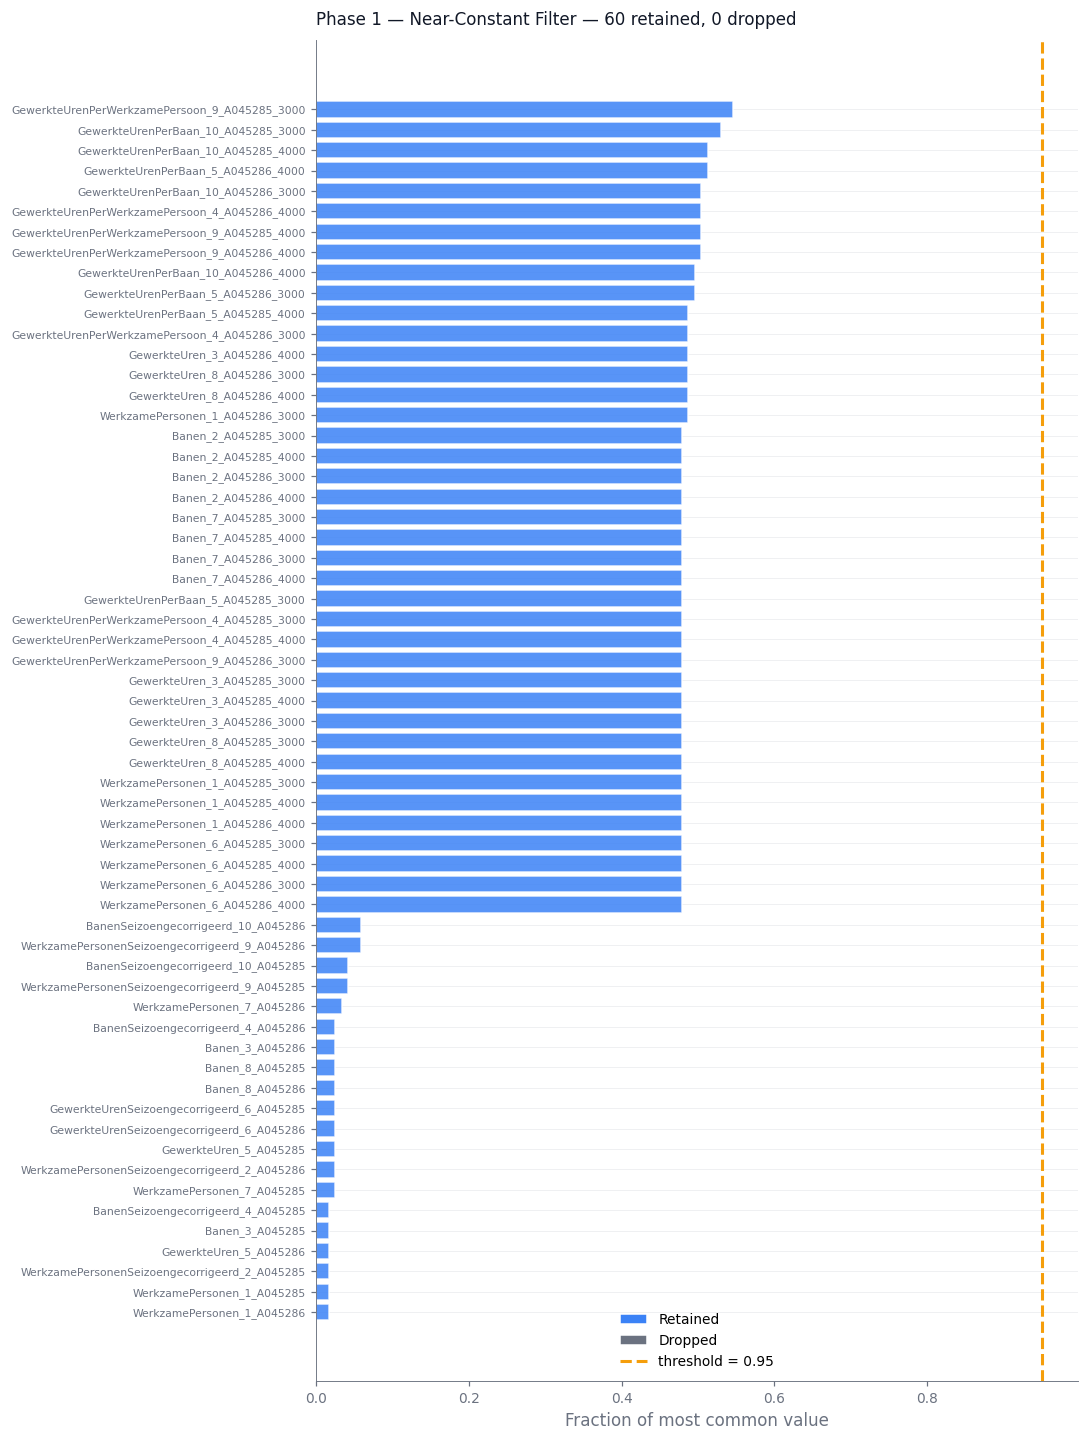

In [ ]:
# ── Visualise: dominant-value fraction per feature ───────────────────────
scores_nc = result_nc["scores"]
sorted_feats = sorted(scores_nc, key=lambda f: scores_nc[f], reverse=True)
fracs = [scores_nc[f] for f in sorted_feats]

fig, ax = plt.subplots(figsize=(10, max(3.5, len(sorted_feats) * 0.22)))
colors = [DROPPED_COLOR if scores_nc[f] > NC_THRESHOLD else RETAINED_COLOR
          for f in sorted_feats]
ax.barh(range(len(sorted_feats)), fracs, color=colors, edgecolor="white", alpha=0.85)
threshold_line = ax.axvline(x=NC_THRESHOLD, color=ACCENT_COLOR, ls="--", lw=2,
                            label=f"threshold = {NC_THRESHOLD}")
ax.set_yticks(range(len(sorted_feats)))
ax.set_yticklabels(sorted_feats, fontsize=7)
ax.set_xlabel("Fraction of most common value")
ax.set_title(f"Phase 1 — Near-Constant Filter — "
             f"{len(result_nc['retained'])} retained, {len(result_nc['dropped'])} dropped")
ax.legend(handles=_legend_handles() + [threshold_line])
ax.invert_yaxis()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

---
## Phase 2 — Independent Signal Detection

Each of the four filters below evaluates **all** Phase 1 survivors independently.
No filter's output affects another filter's input. At the end of Phase 2, we combine
the results into a consensus vote.

| Method | What it measures | Temporal perspective | Toggle |
|--------|-----------------|---------------------|--------|
| **2A. Correlation** | Linear association after within-sector differencing | Contemporaneous (same quarter) | `APPLY_CORRELATION` |
| **2B. Lagged Correlation** | Linear association at forecast horizons h=1,2,3 | Forward-looking | `APPLY_LAGGED` |
| **2C. Granger Causality** | Whether past values predict future target beyond autoregression | Forward-looking (statistical test) | `APPLY_GRANGER` |
| **2D. Lasso Stability** | Whether regularised regression consistently selects the feature | Forecast-aligned (h=1,2,3) | `APPLY_LASSO` |

Set any `APPLY_*` to `False` to exclude it from the consensus vote. The filter still
runs (so you can inspect its visualisation), but its result won't count toward the vote.

### 2A — Contemporaneous Correlation

Computes `corr(Δfeature, Δtarget)` after within-sector first-differencing.

**Why within-sector differencing?** A naive pooled correlation can be driven by
level differences between sectors (one sector always has high jobs AND high
absenteeism). First-differencing within each sector removes these level effects
and captures temporal co-movement: *"When this feature changes in this sector,
does absenteeism change too?"*

| Parameter | Value | Effect |
|---|---|---|
| `CORR_THRESHOLD` | 0.05 | Minimum |r| to pass. Higher = stricter. |

In [ ]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────
APPLY_CORRELATION = True       # include in consensus vote?
# ─── PARAMETER ────────────────────────────────────────────────────────────
CORR_THRESHOLD    = 0.05       # ← adjust this
# ──────────────────────────────────────────────────────────────────────────

result_corr = apply_correlation_filter(
    phase2_features, df, target=TARGET,
    threshold=CORR_THRESHOLD,
    method="within_sector_differenced",
    sector_col=SECTOR_COL,
)
print(f"APPLY: {APPLY_CORRELATION}")
print(f"  Input    : {len(result_corr['input'])} features")
print(f"  Retained : {len(result_corr['retained'])} features")
print(f"  Dropped  : {len(result_corr['dropped'])} features")

APPLY: True
  Input    : 60 features
  Retained : 36 features
  Dropped  : 24 features


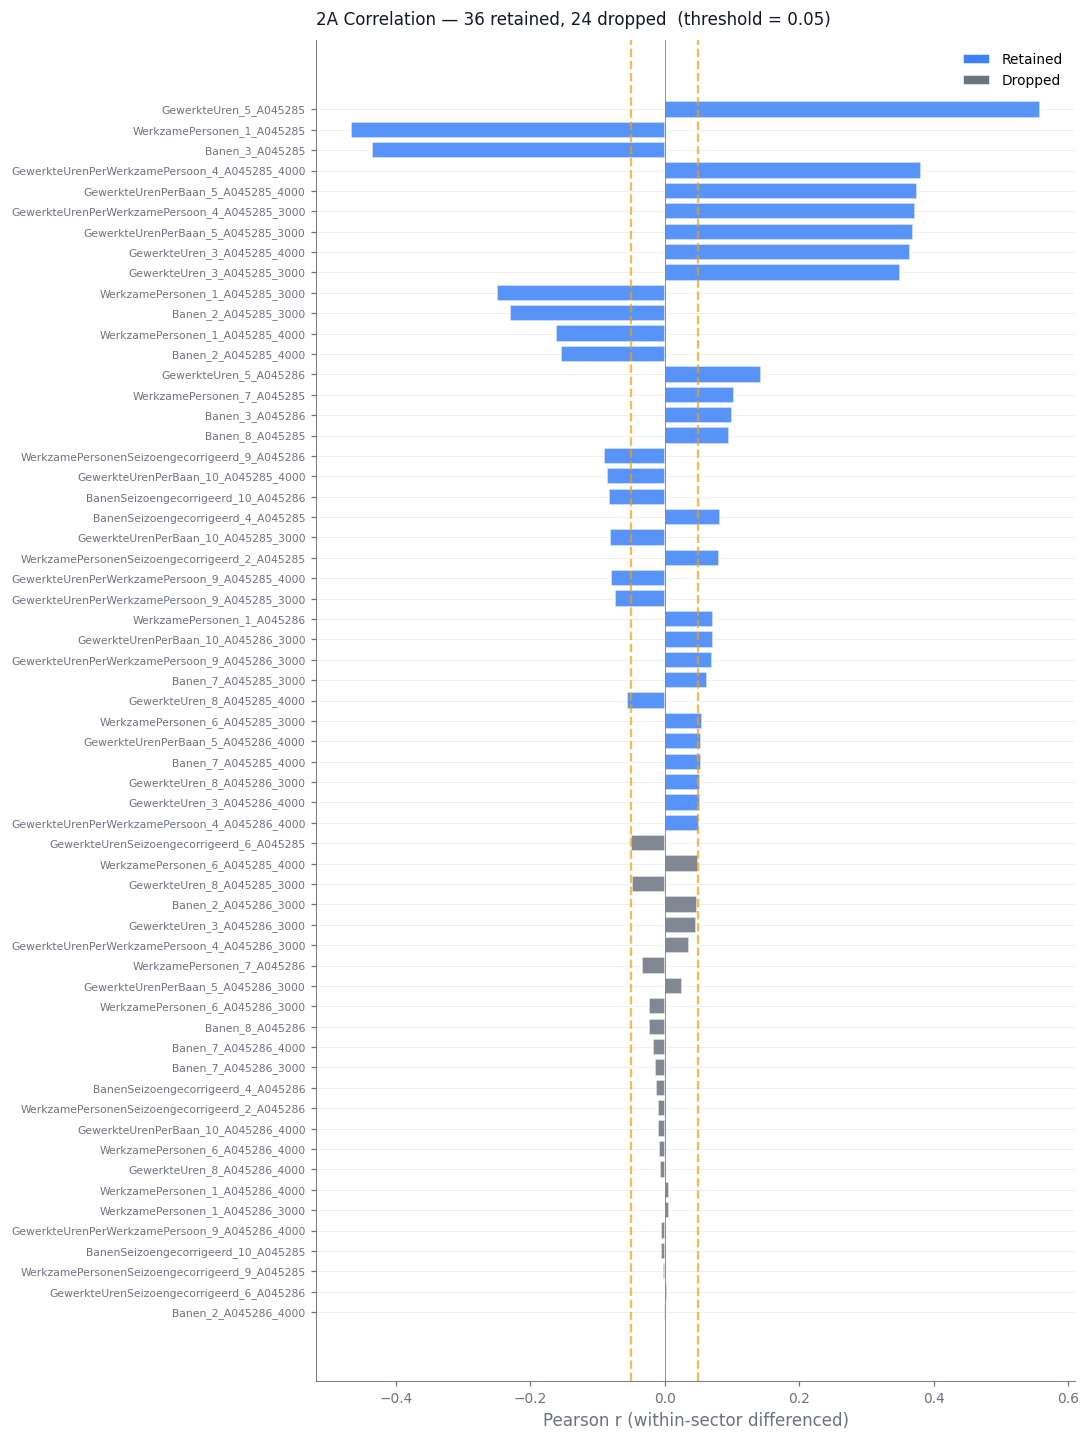

In [ ]:
scores_corr = result_corr["scores"]
sorted_feats = sorted(scores_corr, key=lambda f: abs(scores_corr[f]), reverse=True)

fig, ax = plt.subplots(figsize=(10, max(3.5, len(sorted_feats) * 0.22)))
colors = [RETAINED_COLOR if abs(scores_corr[f]) >= CORR_THRESHOLD else DROPPED_COLOR
          for f in sorted_feats]
ax.barh(range(len(sorted_feats)), [scores_corr[f] for f in sorted_feats],
        color=colors, edgecolor="white", alpha=0.85)
for sign in [1, -1]:
    ax.axvline(x=sign * CORR_THRESHOLD, color=ACCENT_COLOR, ls="--", lw=1.5, alpha=0.7)
ax.axvline(x=0, color=C_GREY, ls="-", lw=0.5)
ax.set_yticks(range(len(sorted_feats)))
ax.set_yticklabels(sorted_feats, fontsize=7)
ax.set_xlabel("Pearson r (within-sector differenced)")
ax.set_title(f"2A Correlation — {len(result_corr['retained'])} retained, "
             f"{len(result_corr['dropped'])} dropped  (threshold = {CORR_THRESHOLD})")
ax.legend(handles=_legend_handles())
ax.invert_yaxis()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Reading the chart:** The sign matters — negative correlation means the feature moves
opposite to absenteeism (e.g., more jobs → less absenteeism).

### 2B — Lagged Correlation (Predictive Value)

Computes `corr(feature_t, target_{t+h})` for forecast horizons h ∈ {1, 2, 3} quarters
ahead, within each sector. Scores are aggregated across sectors using the median.
A feature passes if its score meets the threshold at **any** horizon.

**Why this complements 2A:** A feature with zero contemporaneous correlation but strong
correlation at lag 3 is a **leading indicator** — exactly what a forecasting model needs.
The correlation filter (2A) would miss it entirely.

| Parameter | Value | Effect |
|---|---|---|
| `LAGGED_THRESHOLD` | 0.08 | Min median |r| at any horizon. Lower than 2A because lagged signals decay over forecast horizons. |

In [ ]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────
APPLY_LAGGED = True            # include in consensus vote?
# ─── PARAMETER ────────────────────────────────────────────────────────────
LAGGED_THRESHOLD = 0.08        # ← adjust this
# ──────────────────────────────────────────────────────────────────────────

result_lag = apply_lagged_correlation_filter(
    phase2_features, df, target=TARGET,
    threshold=LAGGED_THRESHOLD,
    horizons=[1, 2, 3],
    sector_col=SECTOR_COL,
)
print(f"APPLY: {APPLY_LAGGED}")
print(f"  Input    : {len(result_lag['input'])} features")
print(f"  Retained : {len(result_lag['retained'])} features")
print(f"  Dropped  : {len(result_lag['dropped'])} features")

APPLY: True
  Input    : 60 features
  Retained : 58 features
  Dropped  : 2 features


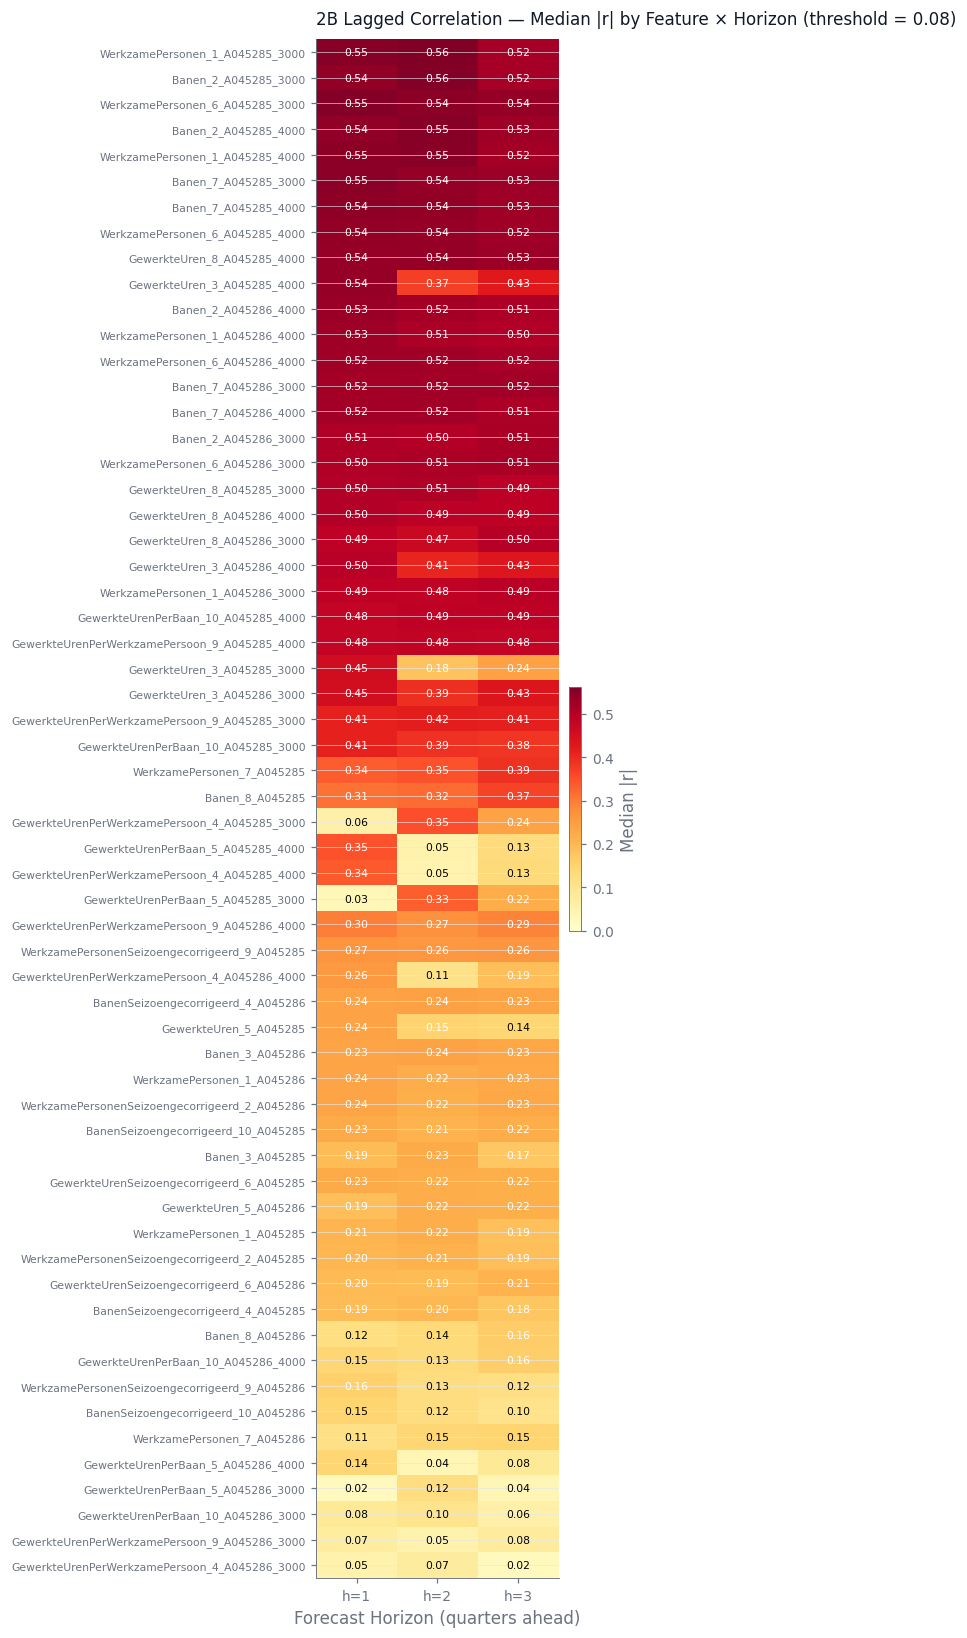

In [ ]:
lag_scores = result_lag["scores"]
horizons = [1, 2, 3]
sorted_feats = sorted(lag_scores, key=lambda f: max(lag_scores[f].values()), reverse=True)
matrix = np.array([[lag_scores[f].get(h, 0) for h in horizons] for f in sorted_feats])

fig, ax = plt.subplots(figsize=(6, max(4, len(sorted_feats) * 0.25)))
im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto", vmin=0)
ax.set_xticks(range(len(horizons)))
ax.set_xticklabels([f"h={h}" for h in horizons])
ax.set_yticks(range(len(sorted_feats)))
ax.set_yticklabels(sorted_feats, fontsize=7)
ax.set_xlabel("Forecast Horizon (quarters ahead)")
ax.set_title(f"2B Lagged Correlation — Median |r| by Feature × Horizon "
             f"(threshold = {LAGGED_THRESHOLD})")
for i in range(len(sorted_feats)):
    for j in range(len(horizons)):
        color = "white" if matrix[i, j] > 0.15 else "black"
        ax.text(j, i, f"{matrix[i,j]:.2f}", ha="center", va="center",
                fontsize=7, color=color)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Median |r|")
plt.tight_layout()
plt.show()

**Reading the chart:** Darker = stronger predictive lead. Compare across horizons:
a feature strong at h=3 but weak at h=1 is a slow-moving leading indicator.

### 2C — Granger Causality

Tests whether *past values of a feature* improve predictions of absenteeism
*beyond what past absenteeism alone provides*. The test is run per sector
(Granger requires a single time series), and a feature passes if it's significant
in ≥ `MIN_SECTOR_FRACTION` of sectors.

#### How the test works (simplified)
1. **Baseline:** predict `target_t` from its own past values (autoregressive model).
2. **Augmented:** add past values of the feature to the model.
3. If the augmented model is significantly better (F-test, p < 0.05), the feature
   "Granger-causes" the target in that sector.

| Parameter | Value | Effect |
|---|---|---|
| `GRANGER_MAX_LAG` | 4 | Test up to 4 quarters of history |
| `GRANGER_P` | 0.05 | Significance level for the F-test |
| `MIN_SECTOR_FRACTION` | 0.20 | Must be significant in ≥ 20% of sectors |
| `GRANGER_DIFFERENCE` | True | First-difference before testing — essential for non-stationary macroeconomic data |

⏱️ *Runtime: ~15–30 seconds.*

In [ ]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────
APPLY_GRANGER = True           # include in consensus vote?
# ─── PARAMETERS ───────────────────────────────────────────────────────────
GRANGER_MAX_LAG      = 4       # ← adjust this
GRANGER_P            = 0.05
MIN_SECTOR_FRACTION  = 0.20    # ← adjust this
GRANGER_DIFFERENCE   = True
# ──────────────────────────────────────────────────────────────────────────

result_granger = apply_granger_filter(
    phase2_features, df, target=TARGET,
    max_lag=GRANGER_MAX_LAG,
    p_threshold=GRANGER_P,
    min_sector_fraction=MIN_SECTOR_FRACTION,
    sector_col=SECTOR_COL,
    difference=GRANGER_DIFFERENCE,
)
print(f"APPLY: {APPLY_GRANGER}")
print(f"  Input    : {len(result_granger['input'])} features")
print(f"  Retained : {len(result_granger['retained'])} features")
print(f"  Dropped  : {len(result_granger['dropped'])} features")

APPLY: True
  Input    : 60 features
  Retained : 41 features
  Dropped  : 19 features


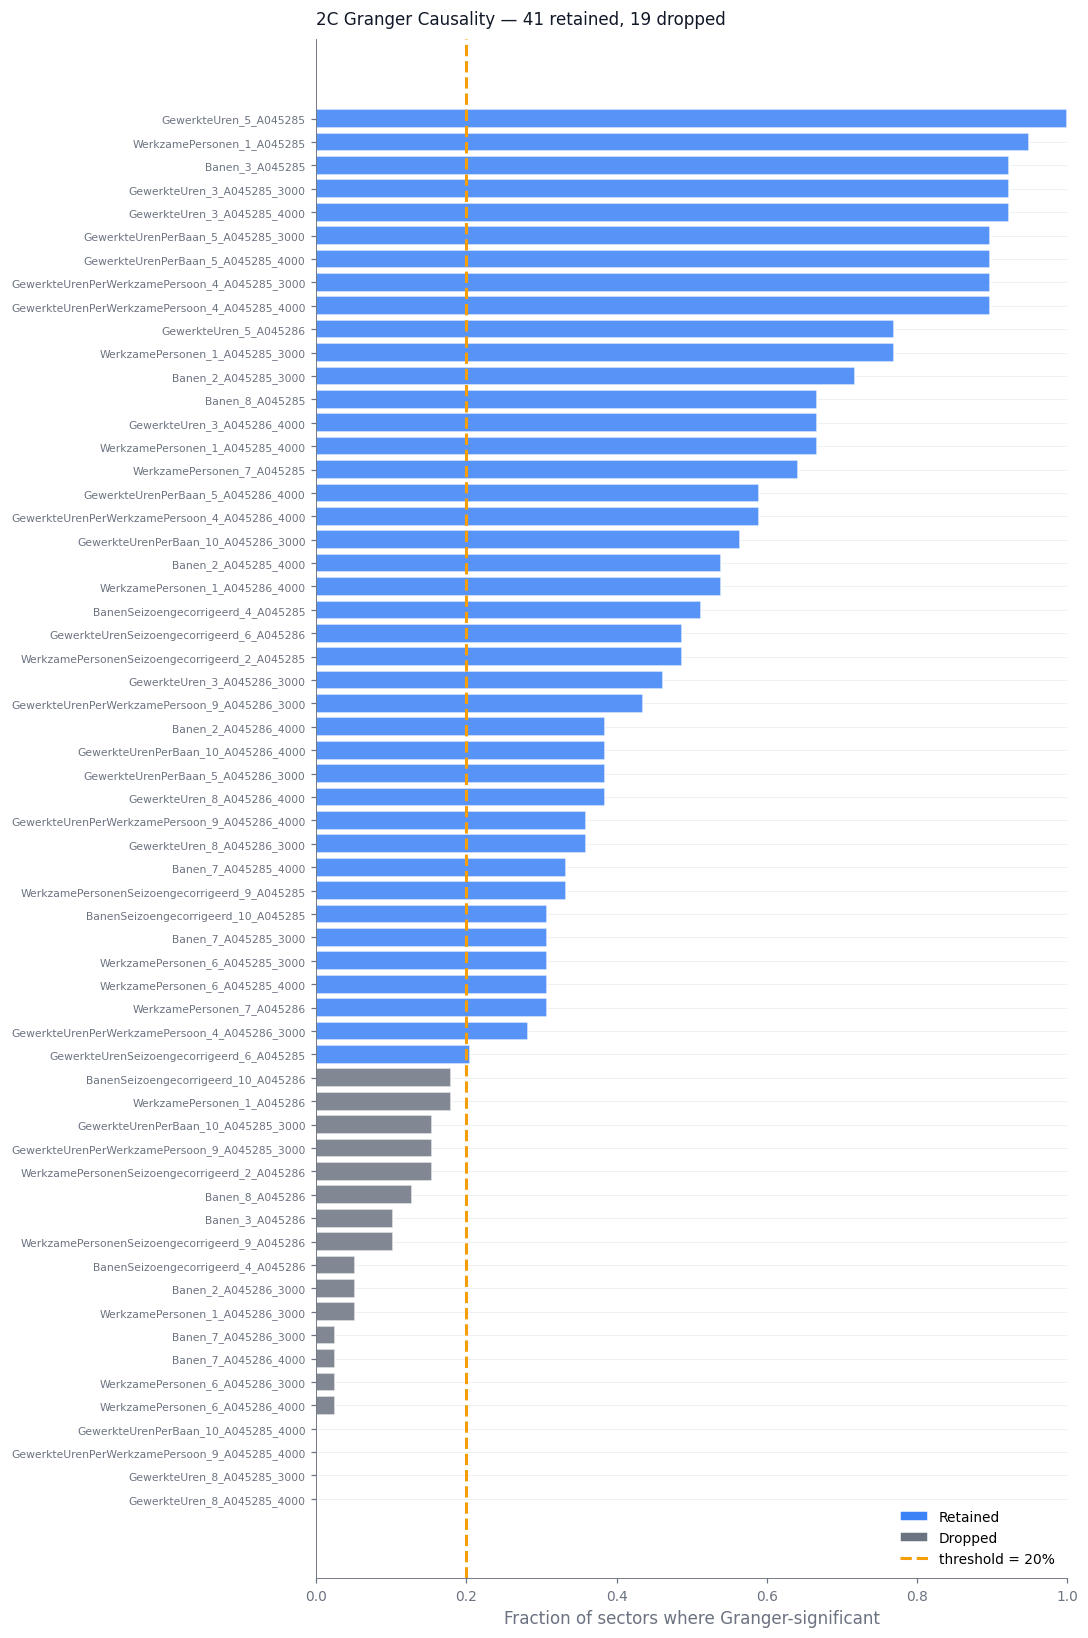

In [ ]:
scores_gr = result_granger["scores"]
sorted_feats = sorted(scores_gr, key=lambda f: scores_gr[f], reverse=True)

fig, ax = plt.subplots(figsize=(10, max(3.5, len(sorted_feats) * 0.25)))
colors = [RETAINED_COLOR if scores_gr[f] >= MIN_SECTOR_FRACTION else DROPPED_COLOR
          for f in sorted_feats]
ax.barh(range(len(sorted_feats)), [scores_gr[f] for f in sorted_feats],
        color=colors, edgecolor="white", alpha=0.85)
threshold_line = ax.axvline(x=MIN_SECTOR_FRACTION, color=ACCENT_COLOR, ls="--", lw=2,
                            label=f"threshold = {MIN_SECTOR_FRACTION:.0%}")
ax.set_yticks(range(len(sorted_feats)))
ax.set_yticklabels(sorted_feats, fontsize=7)
ax.set_xlabel("Fraction of sectors where Granger-significant")
ax.set_title(f"2C Granger Causality — {len(result_granger['retained'])} retained, "
             f"{len(result_granger['dropped'])} dropped")
ax.legend(handles=_legend_handles() + [threshold_line])
ax.invert_yaxis()
ax.set_xlim(0, 1)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Reading the chart:** A feature at 0.60 is a significant predictor in 60% of industry
sectors — a robust cross-sector leading indicator.

### 2D — Lasso Stability Selection (Forecast-Aligned)

Lasso is a linear model that sets some coefficients to exactly zero. But its selection
is **unstable**: small data changes can flip which features are chosen. **Stability
selection** fixes this by running Lasso on 50 bootstrap samples and counting how often
each feature gets a non-zero coefficient.

**Forecast-aligned mode:** instead of testing `feature_t → target_t` (contemporaneous),
we test `feature_t → target_{t+h}` for each horizon h ∈ {1,2,3} — the exact relationship
the downstream model will use. The target is shifted within each sector to avoid
cross-sector contamination. Each feature's final selection probability is the **maximum
across horizons** (passes if Lasso selects it at any forecast horizon).

| Parameter | Value | Effect |
|---|---|---|
| `LASSO_N_BOOTS` | 50 | Number of bootstrap samples. More = more stable but slower |
| `LASSO_THRESHOLD` | 0.50 | Min selection probability (50% = selected in ≥ half the bootstraps) |

⏱️ *Runtime: ~3–5 minutes (50 bootstraps × 3 horizons).*

In [ ]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────
APPLY_LASSO = True             # include in consensus vote?
# ─── PARAMETERS ───────────────────────────────────────────────────────────
LASSO_N_BOOTS   = 50           # ← adjust this
LASSO_THRESHOLD = 0.50         # ← adjust this
# ──────────────────────────────────────────────────────────────────────────

result_lasso = apply_lasso_stability_filter(
    phase2_features, df, target=TARGET,
    n_bootstraps=LASSO_N_BOOTS,
    threshold=LASSO_THRESHOLD,
    random_state=42,
    horizons=[1, 2, 3],
    sector_col=SECTOR_COL,
)
print(f"APPLY: {APPLY_LASSO}")
print(f"  Input    : {len(result_lasso['input'])} features")
print(f"  Retained : {len(result_lasso['retained'])} features")
print(f"  Dropped  : {len(result_lasso['dropped'])} features")

APPLY: True
  Input    : 60 features
  Retained : 53 features
  Dropped  : 7 features


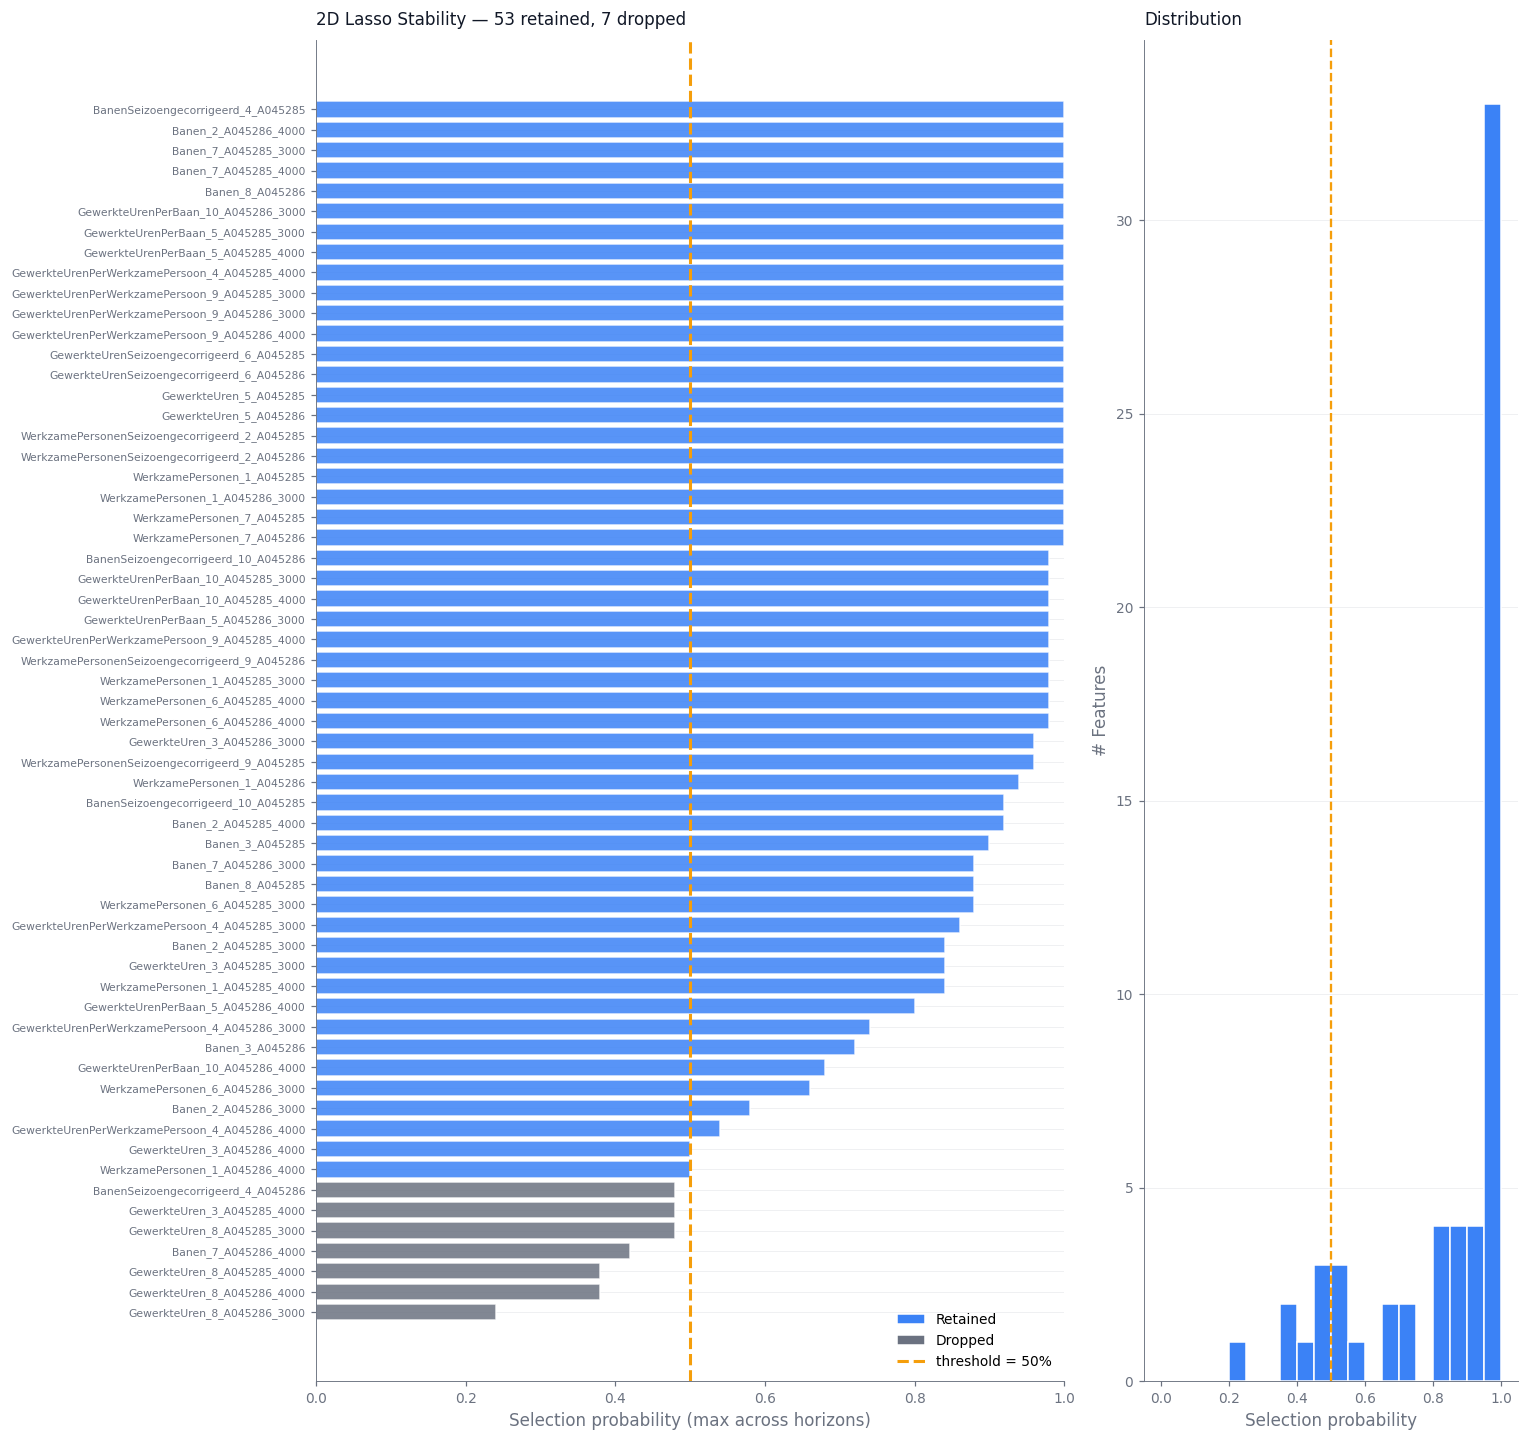

In [ ]:
scores_la = result_lasso["scores"]
sorted_feats = sorted(scores_la, key=lambda f: scores_la[f], reverse=True)
probs = [scores_la[f] for f in sorted_feats]

fig, axes = plt.subplots(1, 2, figsize=(14, max(3.5, len(sorted_feats) * 0.22)),
                          gridspec_kw={"width_ratios": [2, 1]})

colors = [RETAINED_COLOR if scores_la[f] >= LASSO_THRESHOLD else DROPPED_COLOR
          for f in sorted_feats]
axes[0].barh(range(len(sorted_feats)), probs, color=colors, edgecolor="white", alpha=0.85)
threshold_line = axes[0].axvline(x=LASSO_THRESHOLD, color=ACCENT_COLOR, ls="--", lw=2,
                                 label=f"threshold = {LASSO_THRESHOLD:.0%}")
axes[0].set_yticks(range(len(sorted_feats)))
axes[0].set_yticklabels(sorted_feats, fontsize=7)
axes[0].set_xlabel("Selection probability (max across horizons)")
axes[0].set_title(f"2D Lasso Stability — {len(result_lasso['retained'])} retained, "
                  f"{len(result_lasso['dropped'])} dropped")
axes[0].legend(handles=_legend_handles() + [threshold_line])
axes[0].invert_yaxis()
axes[0].set_xlim(0, 1)
sns.despine(ax=axes[0])

axes[1].hist(probs, bins=20, range=(0, 1), color=RETAINED_COLOR, edgecolor="white")
axes[1].axvline(x=LASSO_THRESHOLD, color=ACCENT_COLOR, ls="--", lw=1.5)
axes[1].set_xlabel("Selection probability")
axes[1].set_ylabel("# Features")
axes[1].set_title("Distribution")
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

**Reading the charts:**
- **Left:** Green = reliably selected (≥50%), Grey = unreliable. Each probability
  is the **maximum across horizons h=1,2,3**: a feature showing 0.80 was selected in
  80% of bootstraps at its best horizon.
- **Right:** Ideally bimodal — a cluster near 1.0 (always selected) and a cluster
  near 0.0 (never selected). Features in the 0.3–0.6 zone are swing features.

---
## Phase 3 — Consensus Voting

Each feature was independently evaluated by the **active** Phase 2 filters (those with
`APPLY_* = True`). A feature is retained if it passes **≥ K** of the active filters.

Each method has blind spots:
- Correlation misses non-linear relationships.
- Granger requires stationarity and can fail on short series.
- Lasso assumes a linear feature–target relationship and may miss non-linear predictors.
- Lagged correlation doesn't account for autoregressive structure.

Multi-method agreement compensates for individual weaknesses.

### Choosing the vote threshold
- **K=1** (union): permissive, risks false positives.
- **K=2** (majority of 4): balanced default.
- **K=3** (strong consensus): conservative.
- **K=4** (unanimous): very aggressive, may lose good features.

In [ ]:
# ── Build the vote matrix from ACTIVE filters only ───────────────────────
all_results = {
    "Correlation":     (APPLY_CORRELATION, result_corr),
    "Lagged Corr.":    (APPLY_LAGGED,      result_lag),
    "Granger":         (APPLY_GRANGER,      result_granger),
    "Lasso Stability": (APPLY_LASSO,        result_lasso),
}

active_results = {name: res for name, (active, res) in all_results.items() if active}
n_active = len(active_results)

print(f"Active filters: {n_active} / 4")
for name, (active, _) in all_results.items():
    status = "✅ ACTIVE" if active else "⬜ skipped"
    print(f"  {status}  {name}")

vote_df = pd.DataFrame(index=phase2_features)
for name, res in active_results.items():
    retained_set = set(res["retained"])
    vote_df[name] = [f in retained_set for f in phase2_features]

vote_df["Votes"] = vote_df.sum(axis=1)
vote_df = vote_df.sort_values("Votes", ascending=False)

print(f"\nVote matrix ({len(phase2_features)} features × {n_active} active filters):\n")
print(vote_df.to_string())

Active filters: 4 / 4
  ✅ ACTIVE  Correlation
  ✅ ACTIVE  Lagged Corr.
  ✅ ACTIVE  Granger
  ✅ ACTIVE  Lasso Stability

Vote matrix (60 features × 4 active filters):

                                               Correlation  Lagged Corr.  Granger  Lasso Stability  Votes
BanenSeizoengecorrigeerd_4_A045285                    True          True     True             True      4
Banen_7_A045285_3000                                  True          True     True             True      4
Banen_2_A045285_4000                                  True          True     True             True      4
Banen_2_A045285_3000                                  True          True     True             True      4
Banen_7_A045285_4000                                  True          True     True             True      4
Banen_3_A045285                                       True          True     True             True      4
GewerkteUrenPerBaan_5_A045286_4000                    True          True     True          

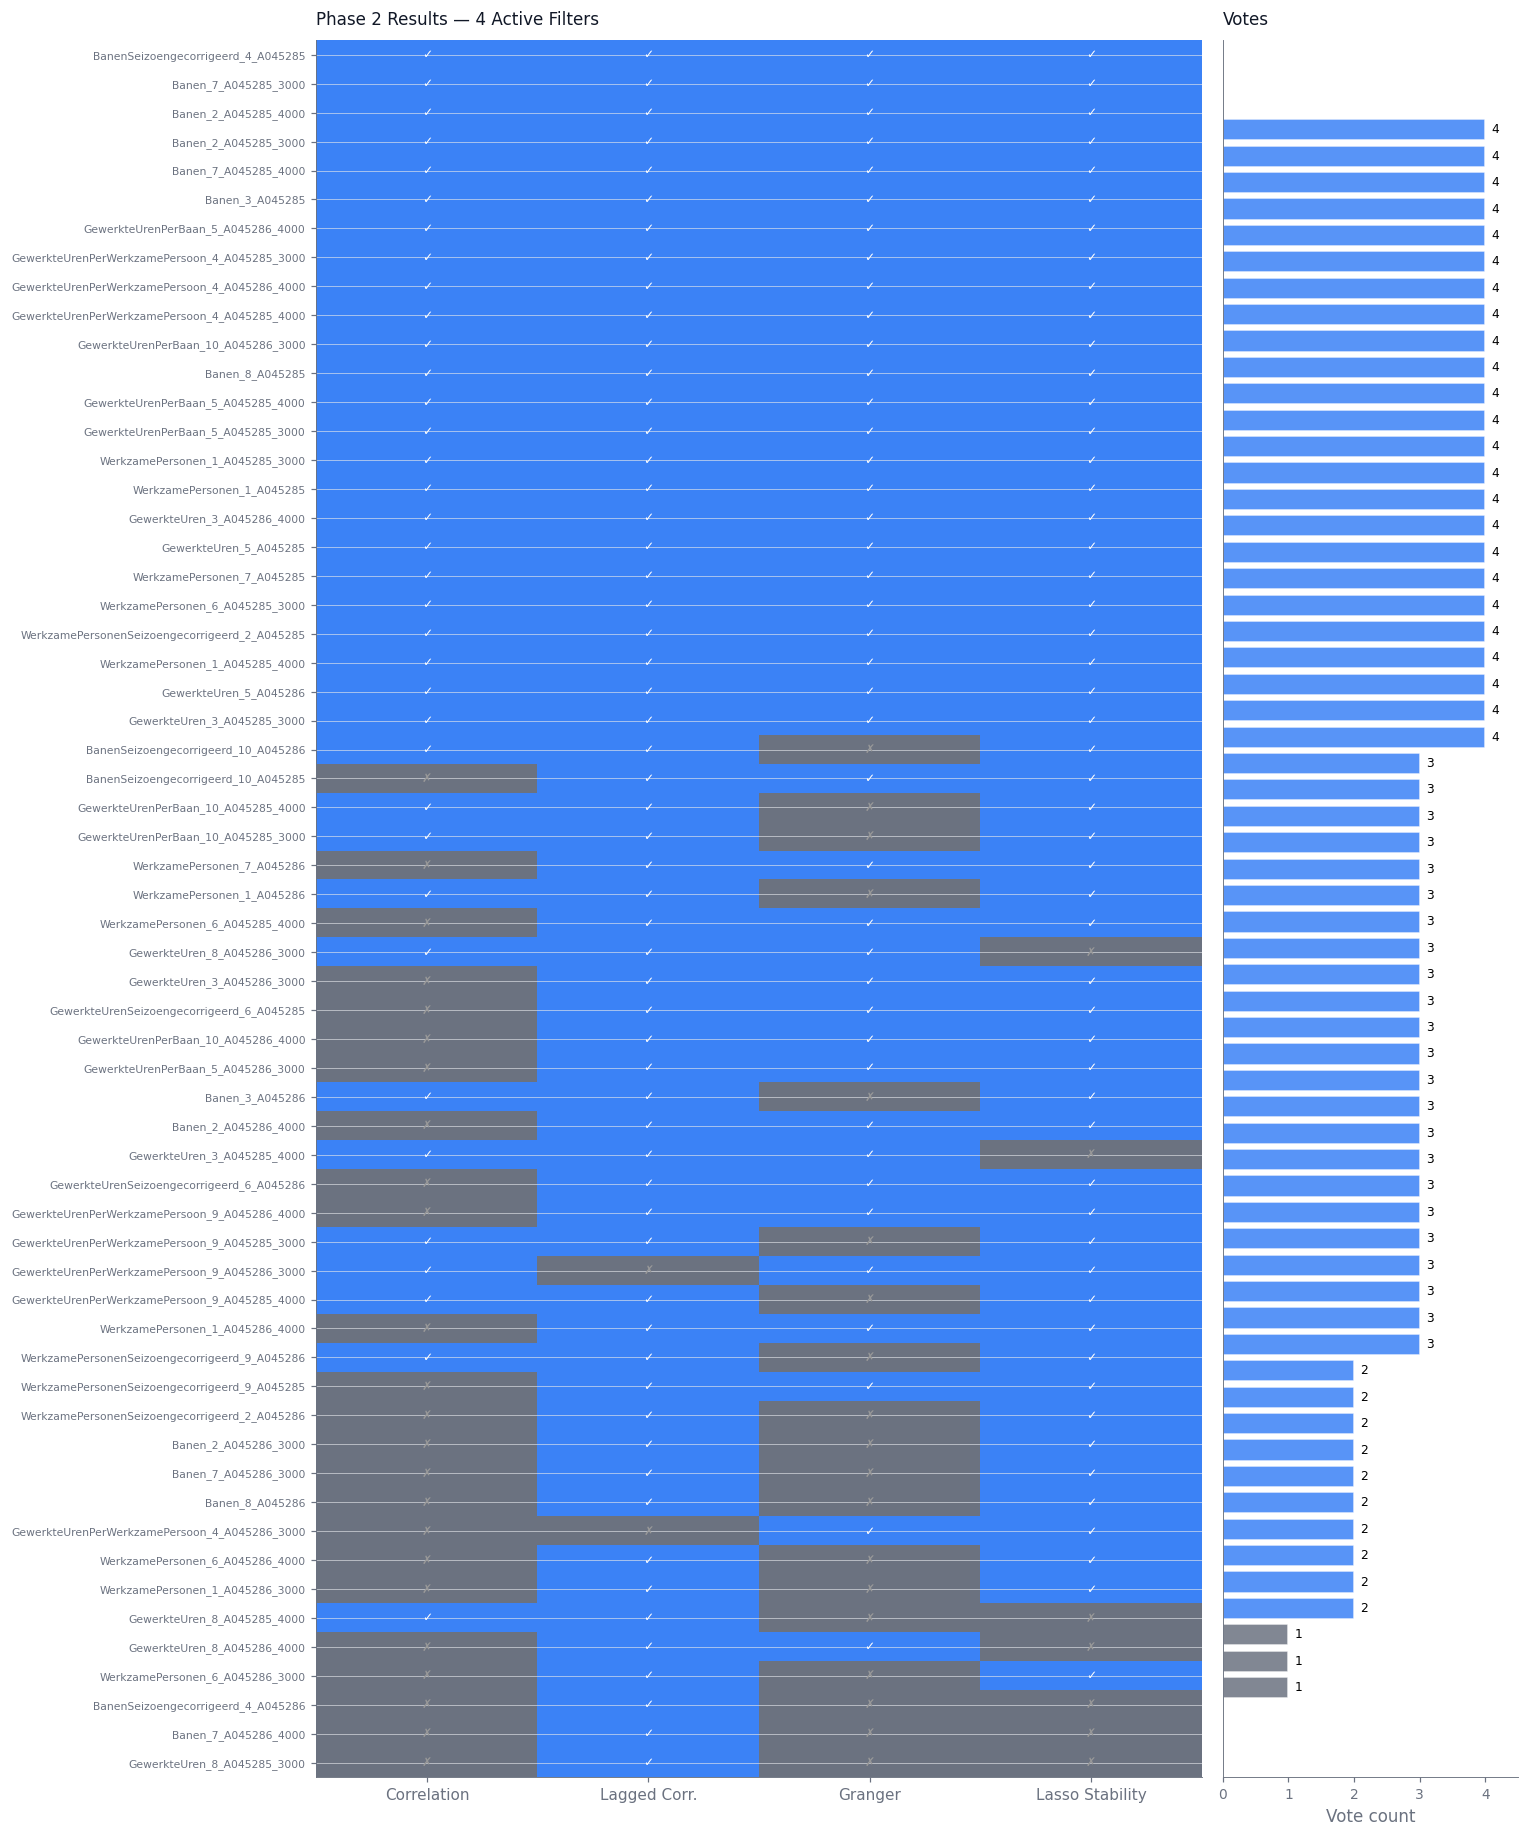

In [ ]:
# ── Visualise: vote matrix heatmap ───────────────────────────────────────
filter_names = list(active_results.keys())
features_sorted = vote_df.index.tolist()
matrix = vote_df[filter_names].values.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(features_sorted) * 0.28)),
                          gridspec_kw={"width_ratios": [3, 1]})

# Left: pass/fail heatmap
cmap_pf = plt.cm.colors.ListedColormap([DROPPED_COLOR, RETAINED_COLOR])
im = axes[0].imshow(matrix, cmap=cmap_pf, aspect="auto", vmin=0, vmax=1)
axes[0].set_xticks(range(len(filter_names)))
axes[0].set_xticklabels(filter_names, fontsize=10)
axes[0].set_yticks(range(len(features_sorted)))
axes[0].set_yticklabels(features_sorted, fontsize=7)
axes[0].set_title(f"Phase 2 Results — {n_active} Active Filters")
for i in range(len(features_sorted)):
    for j in range(len(filter_names)):
        symbol = "✓" if matrix[i, j] else "✗"
        color = "white" if matrix[i, j] else "#999"
        axes[0].text(j, i, symbol, ha="center", va="center", fontsize=8, color=color)

# Right: vote count
vote_counts = vote_df["Votes"].values
bar_colors = [RETAINED_COLOR if v >= 2 else DROPPED_COLOR for v in vote_counts]
axes[1].barh(range(len(features_sorted)), vote_counts, color=bar_colors,
             edgecolor="white", alpha=0.85)
axes[1].set_yticks([])
axes[1].set_xlabel("Vote count")
axes[1].set_title("Votes")
axes[1].set_xlim(0, n_active + 0.5)
axes[1].invert_yaxis()
for i, v in enumerate(vote_counts):
    axes[1].text(v + 0.1, i, str(int(v)), va="center", fontsize=8)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

In [ ]:
# ── Apply vote threshold ────────────────────────────────────────────────
# ╔══════════════════════════════════════════════════════════╗
# ║  ADJUST THIS: change to 1, 2, 3, or up to n_active     ║
# ╚══════════════════════════════════════════════════════════╝
VOTE_THRESHOLD = 2

consensus_survivors = vote_df[vote_df["Votes"] >= VOTE_THRESHOLD].index.tolist()

print(f"Vote threshold: ≥ {VOTE_THRESHOLD} of {n_active} active filters")
print(f"Features passing: {len(consensus_survivors)} / {len(phase2_features)}")
print(f"\nVote distribution:")
for v in range(n_active, -1, -1):
    count = (vote_df["Votes"] == v).sum()
    marker = "  ◀ threshold" if v == VOTE_THRESHOLD else ""
    print(f"  {v} votes: {count:3d} features{marker}")

Vote threshold: ≥ 2 of 4 active filters
Features passing: 57 / 60

Vote distribution:
  4 votes:  24 features
  3 votes:  23 features
  2 votes:  10 features  ◀ threshold
  1 votes:   3 features
  0 votes:   0 features


---
## Scatter Validation

Quick visual sanity check before finalising: does the relationship between each top
consensus survivor and the target look sensible? Scatter plots catch problems that
correlations miss — e.g., a high correlation driven by a single outlier, or a non-linear
relationship that a threshold-based filter misinterprets.

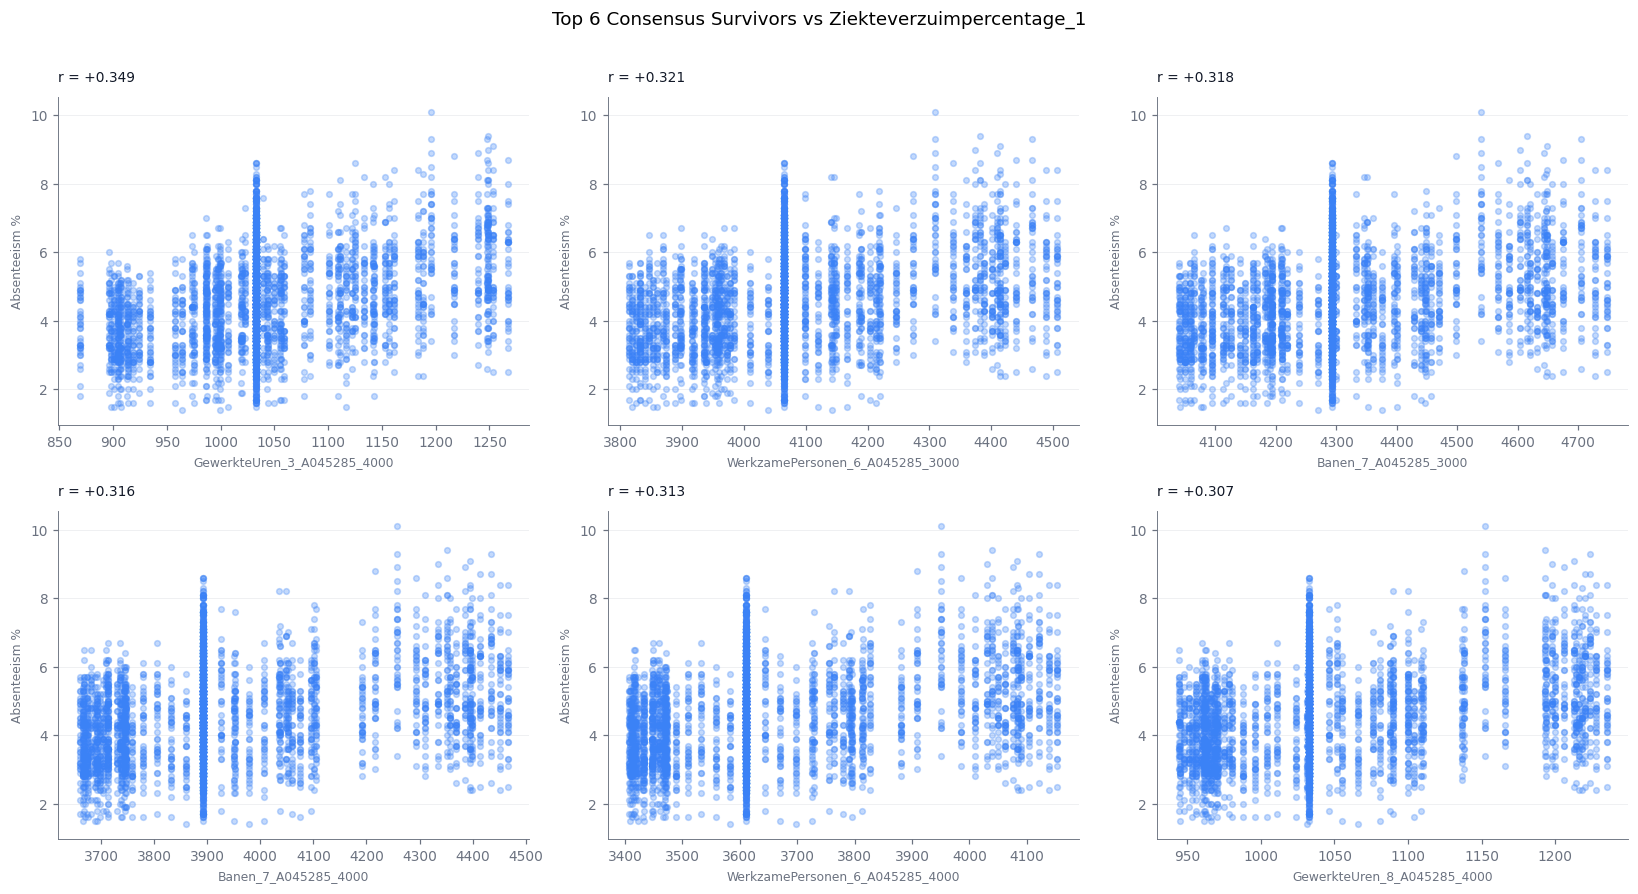

In [ ]:
# ─── PARAMETER ────────────────────────────────────────────────────────────
SCATTER_TOP_N = 6              # ← adjust this
# ──────────────────────────────────────────────────────────────────────────

_corr_rank = (
    df[consensus_survivors]
    .corrwith(df[TARGET])
    .dropna().abs()
    .sort_values(ascending=False)
)
top_features = _corr_rank.head(SCATTER_TOP_N).index.tolist()

ncols = 3
nrows = (len(top_features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = np.array(axes).flatten()

for ax, feat in zip(axes, top_features):
    r = df[feat].corr(df[TARGET])
    ax.scatter(df[feat], df[TARGET], alpha=0.30, s=14, color=RETAINED_COLOR)
    ax.set_xlabel(feat[:45], fontsize=8)
    ax.set_ylabel("Absenteeism %", fontsize=8)
    ax.set_title(f"r = {r:+.3f}", fontsize=9)
    sns.despine(ax=ax)

for ax in axes[len(top_features):]:
    ax.set_visible(False)

plt.suptitle(f"Top {len(top_features)} Consensus Survivors vs {TARGET}",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Redundancy Removal (Post-Consensus)

Now that we know which features are **predictive** (consensus survivors), we safely
remove **redundant** ones. This filter uses **hierarchical clustering** (complete
linkage) on the absolute correlation matrix. "Complete linkage" means two clusters
only merge when *every pair* of features across them has |r| ≥ threshold — the
strictest rule, which avoids chaining artifacts.

From each cluster, the feature with the strongest within-sector differenced target
correlation is kept.

**Why redundancy runs last:** If we removed redundancy before testing, we might keep
the wrong member of a correlated pair — the one with higher contemporaneous correlation,
when the other is the better leading indicator at lag 3.

| Parameter | Value | Effect |
|---|---|---|
| `REDUNDANCY_THRESHOLD` | 0.90 | Features with |r| ≥ this are redundant. Lower = more aggressive. |

In [ ]:
# ─── PARAMETER ────────────────────────────────────────────────────────────
REDUNDANCY_THRESHOLD = 0.90    # ← adjust this
# ──────────────────────────────────────────────────────────────────────────

result_red = apply_redundancy_filter(
    consensus_survivors, df, target=TARGET,
    threshold=REDUNDANCY_THRESHOLD,
    sector_col=SECTOR_COL,
)
print(f"  Input (consensus survivors): {len(result_red['input'])} features")
print(f"  Retained after dedup:        {len(result_red['retained'])} features")
print(f"  Removed as redundant:        {len(result_red['dropped'])} features")

  Input (consensus survivors): 57 features
  Retained after dedup:        20 features
  Removed as redundant:        37 features


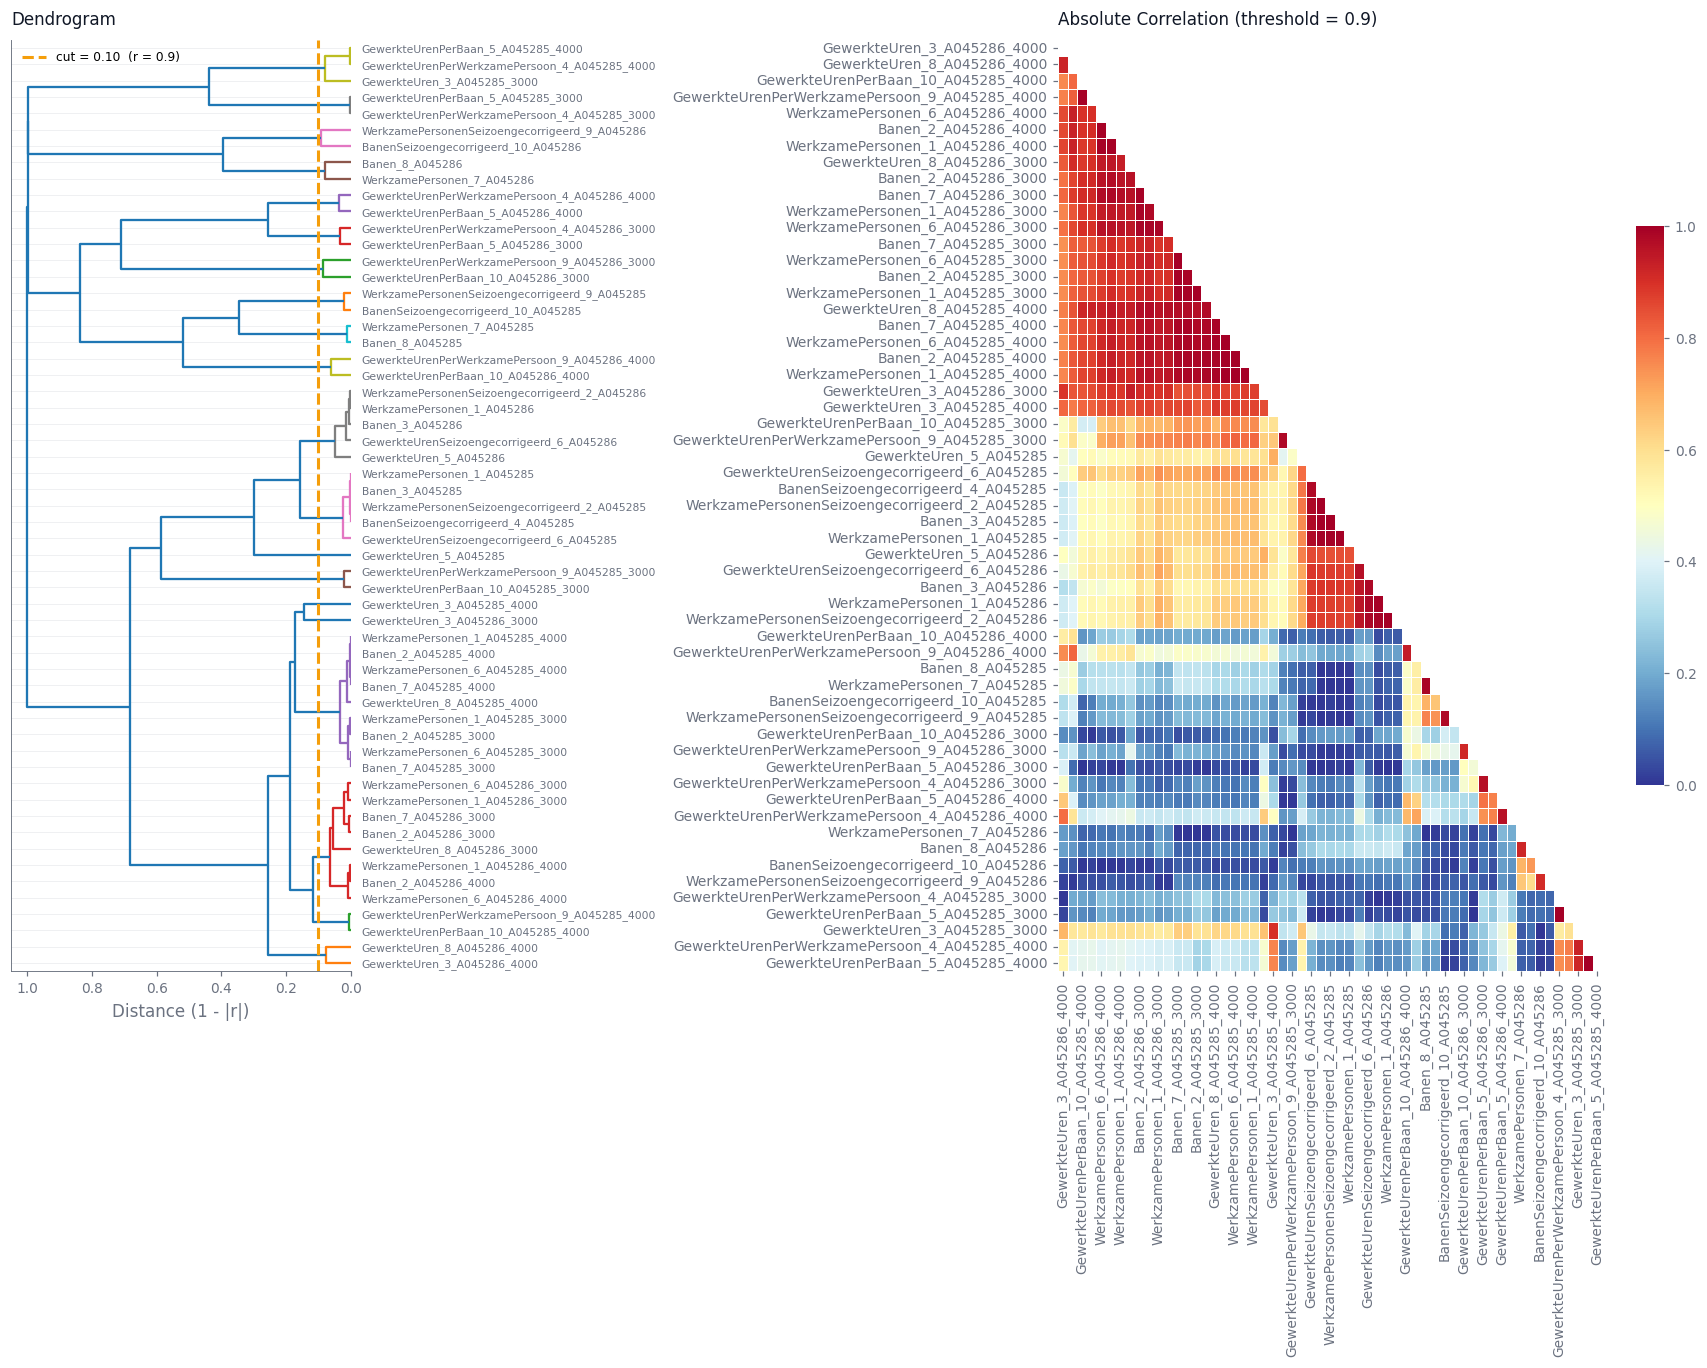

In [ ]:
# ── Visualise: dendrogram + heatmap ──────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

if len(consensus_survivors) > 2:
    with np.errstate(divide="ignore", invalid="ignore"):
        corr = df[consensus_survivors].corr().abs().fillna(0.0)
    np.fill_diagonal(corr.values, 1.0)
    distance = (1.0 - corr).clip(lower=0.0)
    np.fill_diagonal(distance.values, 0.0)
    condensed = squareform(distance.values, checks=False)
    Z = linkage(condensed, method="complete")

    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(consensus_survivors) * 0.22)),
                             gridspec_kw={"width_ratios": [1, 2]})

    dn = dendrogram(Z, labels=consensus_survivors, orientation="left",
                    ax=axes[0], color_threshold=1.0 - REDUNDANCY_THRESHOLD,
                    leaf_font_size=7)
    axes[0].axvline(x=1.0 - REDUNDANCY_THRESHOLD, color=ACCENT_COLOR, ls="--", lw=2,
                    label=f"cut = {1.0 - REDUNDANCY_THRESHOLD:.2f}  (r = {REDUNDANCY_THRESHOLD})")
    axes[0].set_xlabel("Distance (1 - |r|)")
    axes[0].set_title("Dendrogram")
    axes[0].legend(fontsize=8)

    order = dn["leaves"]
    ordered = [consensus_survivors[i] for i in order]
    corr_ord = corr.loc[ordered, ordered]

    mask = np.triu(np.ones_like(corr_ord, dtype=bool))
    sns.heatmap(corr_ord, mask=mask, annot=(len(ordered) <= 20), fmt=".2f",
                cmap="RdYlBu_r", vmin=0, vmax=1, linewidths=0.5,
                annot_kws={"size": 7}, ax=axes[1], cbar_kws={"shrink": 0.6})
    axes[1].set_title(f"Absolute Correlation (threshold = {REDUNDANCY_THRESHOLD})")
    axes[1].grid(False)

    plt.tight_layout()
    plt.show()
else:
    print("≤ 2 consensus survivors — no redundancy analysis needed.")

---
## Pipeline Summary

In [ ]:
final_survivors = result_red["retained"]

# ── Funnel table ─────────────────────────────────────────────────────────
steps = [
    ("Raw features",              len(feature_cols)),
    ("Phase 1: near-constant",    len(phase2_features)),
    (f"Phase 3: consensus (≥{VOTE_THRESHOLD}/{n_active})", len(consensus_survivors)),
    ("Phase 3b: redundancy",      len(final_survivors)),
]

print(f"{'Step':<35s}  {'Count':>6s}  {'Dropped':>7s}")
print("─" * 52)
prev = None
for label, count in steps:
    dropped = f"{prev - count:>7d}" if prev is not None else "      —"
    print(f"{label:<35s}  {count:>6d}  {dropped}")
    prev = count
print("─" * 52)

print(f"\nFinal features ({len(final_survivors)}):")
final_corr = (
    df[final_survivors].corrwith(df[TARGET]).dropna()
    .sort_values(key=abs, ascending=False)
)
for i, (col, r) in enumerate(final_corr.items(), 1):
    print(f"  {i:3d}. {col:55s}  r = {r:+.3f}")

Step                                  Count  Dropped
────────────────────────────────────────────────────
Raw features                             60        —
Phase 1: near-constant                   60        0
Phase 3: consensus (≥2/4)                57        3
Phase 3b: redundancy                     20       37
────────────────────────────────────────────────────

Final features (20):
    1. GewerkteUren_3_A045285_4000                              r = +0.349
    2. WerkzamePersonen_1_A045285_3000                          r = +0.300
    3. GewerkteUren_8_A045286_3000                              r = +0.296
    4. GewerkteUren_3_A045286_3000                              r = +0.274
    5. GewerkteUren_3_A045286_4000                              r = +0.268
    6. GewerkteUrenPerBaan_10_A045285_4000                      r = +0.265
    7. GewerkteUrenPerWerkzamePersoon_4_A045285_4000            r = +0.262
    8. GewerkteUrenPerBaan_10_A045285_3000                      r = -0.255
    9. 

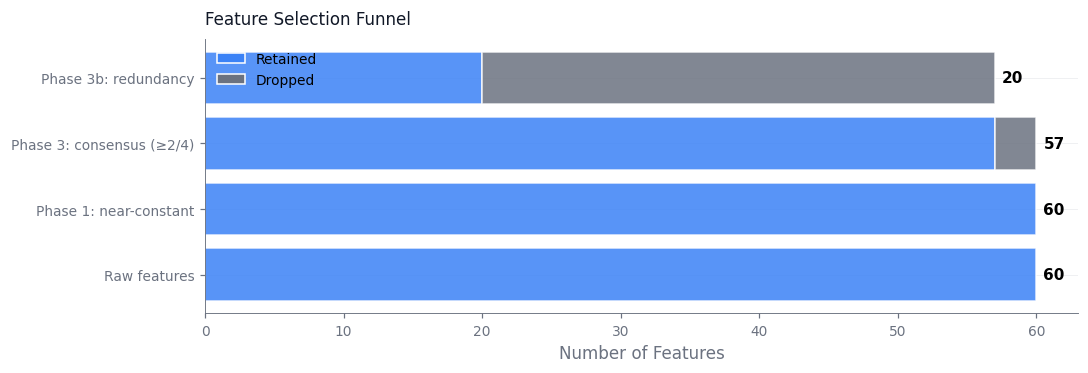

In [ ]:
# ── Funnel chart ─────────────────────────────────────────────────────────
labels = [s[0] for s in steps]
counts = [s[1] for s in steps]
step_dropped = [0] + [prev - curr for prev, curr in zip(counts[:-1], counts[1:])]

fig, ax = plt.subplots(figsize=(10, max(3.5, len(steps) * 0.7)))
for i, (count, dropped) in enumerate(zip(counts, step_dropped)):
    ax.barh(i, count, color=RETAINED_COLOR, edgecolor="white", alpha=0.85)
    if dropped > 0:
        ax.barh(i, dropped, left=count, color=DROPPED_COLOR, edgecolor="white", alpha=0.85)
    ax.text(count + dropped + 0.5, i, str(count), va="center", fontweight="bold")

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("Number of Features")
ax.set_title("Feature Selection Funnel")
ax.legend(handles=_legend_handles())
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

---
## Export to JSON

Auto-group survivors by CBS column prefix and save a JSON preset that
`model_configs.py` reads downstream.

In [ ]:
# ── Auto-group by CBS prefix ────────────────────────────────────────────
groups = build_proposed_groups(final_survivors, SOURCE_TABLE_LOOKUP, MERGE_MAP)
validated_groups, ungrouped = validate_feature_groups(groups, final_survivors)

print(f"Feature groups ({len(validated_groups)}):")
for name, meta in validated_groups.items():
    print(f"  {name}: {len(meta['columns'])} features ({meta['source_table']})")
if ungrouped:
    print(f"\nUngrouped: {ungrouped}")

Feature groups (2):
  labor_volume: 14 features (85920NED)
  workforce: 6 features (85920NED)


In [ ]:
# ── Save preset ─────────────────────────────────────────────────────────
# Change PRESET_NAME for each experiment you want to save.
PRESET_NAME = "notebook_consensus"

filter_chain = [result_nc, result_corr, result_lag, result_granger, result_lasso, result_red]

save_preset_to_json(
    preset_name=PRESET_NAME,
    output_dir=DIR_FEATURE_SELECTION,
    survivors=final_survivors,
    feature_groups=validated_groups,
    filter_chain=filter_chain,
    input_shape=df.shape,
    description=(
        f"Independent evaluation ({n_active} active filters) + "
        f"consensus voting (>={VOTE_THRESHOLD}/{n_active}) + "
        f"redundancy dedup ({REDUNDANCY_THRESHOLD})"
    ),
    ungrouped_survivors=ungrouped,
)

✅ Preset saved: C:\Git\eaisi-uwv\data\feature_selection\preset_notebook_consensus.json  (20 features, 2 groups)


WindowsPath('C:/Git/eaisi-uwv/data/feature_selection/preset_notebook_consensus.json')

---
## Appendix — Per-Sector Feature Relevance Diagnostic

### Why this matters

The feature selection above is **global** — it identifies features that are predictive
*on average* across all 39 SBI sectors. But absenteeism in construction may be driven by
different economic forces than absenteeism in financial services.

This diagnostic does **not** change the selection. It reveals the **heterogeneity** of
feature–target relationships across sectors:

1. **Thesis insight:** Discuss which features are universally predictive versus
   sector-concentrated, and what that means economically.
2. **Architecture validation:** The per-sector models downstream (Ridge, ElasticNet,
   HistGBR) receive the same global feature set but learn **sector-specific weights**.
   This heatmap shows *why* that design works.

### What the heatmap shows

For each feature × sector combination: `corr(Δfeature, Δtarget)` within that sector.
Rows = features (consensus survivors, before redundancy). Columns = sectors.
Color = signed Pearson r (blue = negative, red = positive, white = no relationship).
Both axes are hierarchically clustered.

### How to read it

- **Uniformly coloured rows:** Features consistent across all sectors — most robust.
- **Patchy rows:** Heterogeneous predictive power. The feature is strong in specific
  industries but weak or reversed in others.
- **Columns with strong vertical patterns:** Sectors where many features are
  simultaneously predictive (or not).

In [ ]:
# ── Compute within-sector differenced correlations ───────────────────────
diagnostic_features = consensus_survivors

sector_corr_records = []
for sector, group in df.groupby(SECTOR_COL):
    group_sorted = group.sort_values(TIME_COL)
    diff = group_sorted[diagnostic_features + [TARGET]].diff().iloc[1:]
    for feat in diagnostic_features:
        r = diff[feat].corr(diff[TARGET])
        sector_corr_records.append({
            "feature": feat,
            "sector": str(sector),
            "correlation": r if not np.isnan(r) else 0.0,
        })

sector_corr_df = pd.DataFrame(sector_corr_records)
heatmap_pivot = sector_corr_df.pivot(
    index="feature", columns="sector", values="correlation"
).fillna(0.0)

print(f"Heatmap: {heatmap_pivot.shape[0]} features × {heatmap_pivot.shape[1]} sectors")

Heatmap: 57 features × 39 sectors


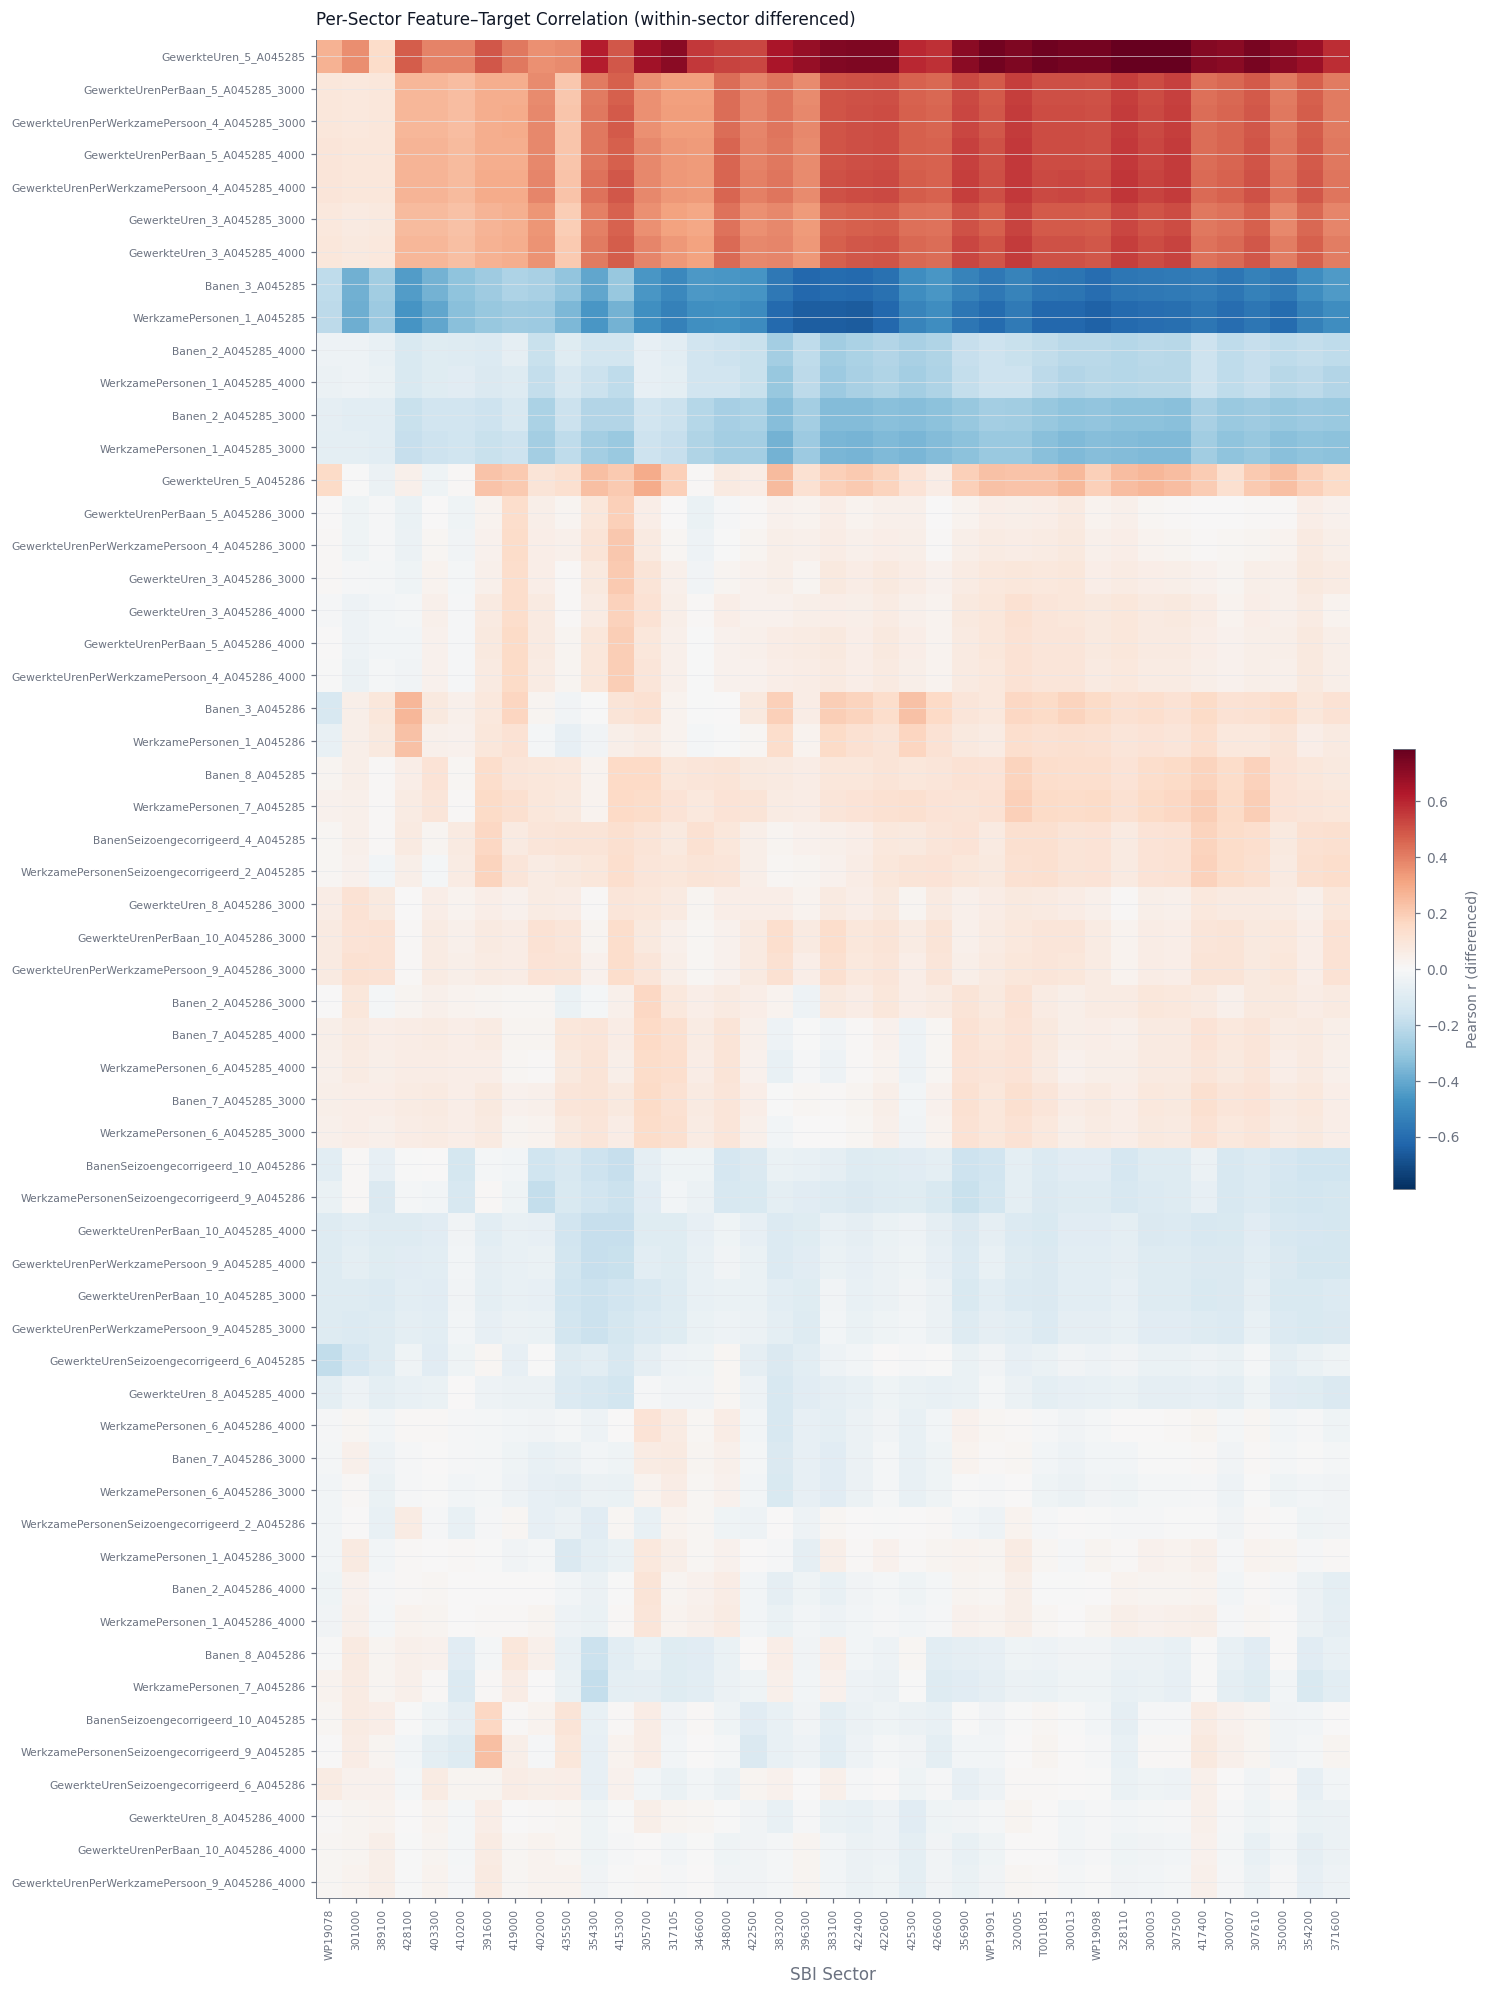

In [ ]:
# ── Biclustered heatmap ──────────────────────────────────────────────────
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

if len(heatmap_pivot) > 2:
    feat_order = leaves_list(linkage(pdist(heatmap_pivot.values, "euclidean"), "ward"))
else:
    feat_order = list(range(len(heatmap_pivot)))

if heatmap_pivot.shape[1] > 2:
    sect_order = leaves_list(linkage(pdist(heatmap_pivot.values.T, "euclidean"), "ward"))
else:
    sect_order = list(range(heatmap_pivot.shape[1]))

ordered_features = [heatmap_pivot.index[i] for i in feat_order]
ordered_sectors  = [heatmap_pivot.columns[j] for j in sect_order]
matrix_diag = heatmap_pivot.loc[ordered_features, ordered_sectors].values

n_feat = len(ordered_features)
n_sect = len(ordered_sectors)
vmax = max(0.3, np.abs(matrix_diag).max())

fig, ax = plt.subplots(figsize=(max(12, n_sect * 0.35), max(6, n_feat * 0.32)))
im = ax.imshow(matrix_diag, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(n_sect))
ax.set_xticklabels(ordered_sectors, rotation=90, fontsize=7)
ax.set_yticks(range(n_feat))
ax.set_yticklabels(ordered_features, fontsize=7)
ax.set_xlabel("SBI Sector")
ax.set_title("Per-Sector Feature–Target Correlation (within-sector differenced)")
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)
cbar.set_label("Pearson r (differenced)", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ── Sign consistency analysis ────────────────────────────────────────────
stability = pd.DataFrame({
    "mean_r":       heatmap_pivot.mean(axis=1),
    "std_r":        heatmap_pivot.std(axis=1),
    "median_abs_r": heatmap_pivot.abs().median(axis=1),
    "n_positive":   (heatmap_pivot > 0.05).sum(axis=1),
    "n_negative":   (heatmap_pivot < -0.05).sum(axis=1),
    "n_neutral":    ((heatmap_pivot >= -0.05) & (heatmap_pivot <= 0.05)).sum(axis=1),
})
stability["sign_consistency"] = (
    (stability["n_positive"] - stability["n_negative"]).abs()
    / (stability["n_positive"] + stability["n_negative"]).replace(0, np.nan)
).fillna(0.0)
stability = stability.sort_values("sign_consistency", ascending=False)

print("Feature stability across sectors")
print("(sign_consistency: 1.0 = same sign everywhere, 0.0 = equally split)\n")
print(stability.to_string(float_format="{:.3f}".format))

Feature stability across sectors
(sign_consistency: 1.0 = same sign everywhere, 0.0 = equally split)

                                               mean_r  std_r  median_abs_r  n_positive  n_negative  n_neutral  sign_consistency
feature                                                                                                                        
BanenSeizoengecorrigeerd_10_A045286            -0.092  0.050         0.094           0          31          8             1.000
Banen_3_A045285                                -0.467  0.119         0.489           0          39          0             1.000
BanenSeizoengecorrigeerd_4_A045285              0.088  0.041         0.093          31           0          8             1.000
Banen_2_A045285_3000                           -0.247  0.079         0.270           0          39          0             1.000
Banen_2_A045285_4000                           -0.166  0.064         0.178           0          37          2             1.000
Ge

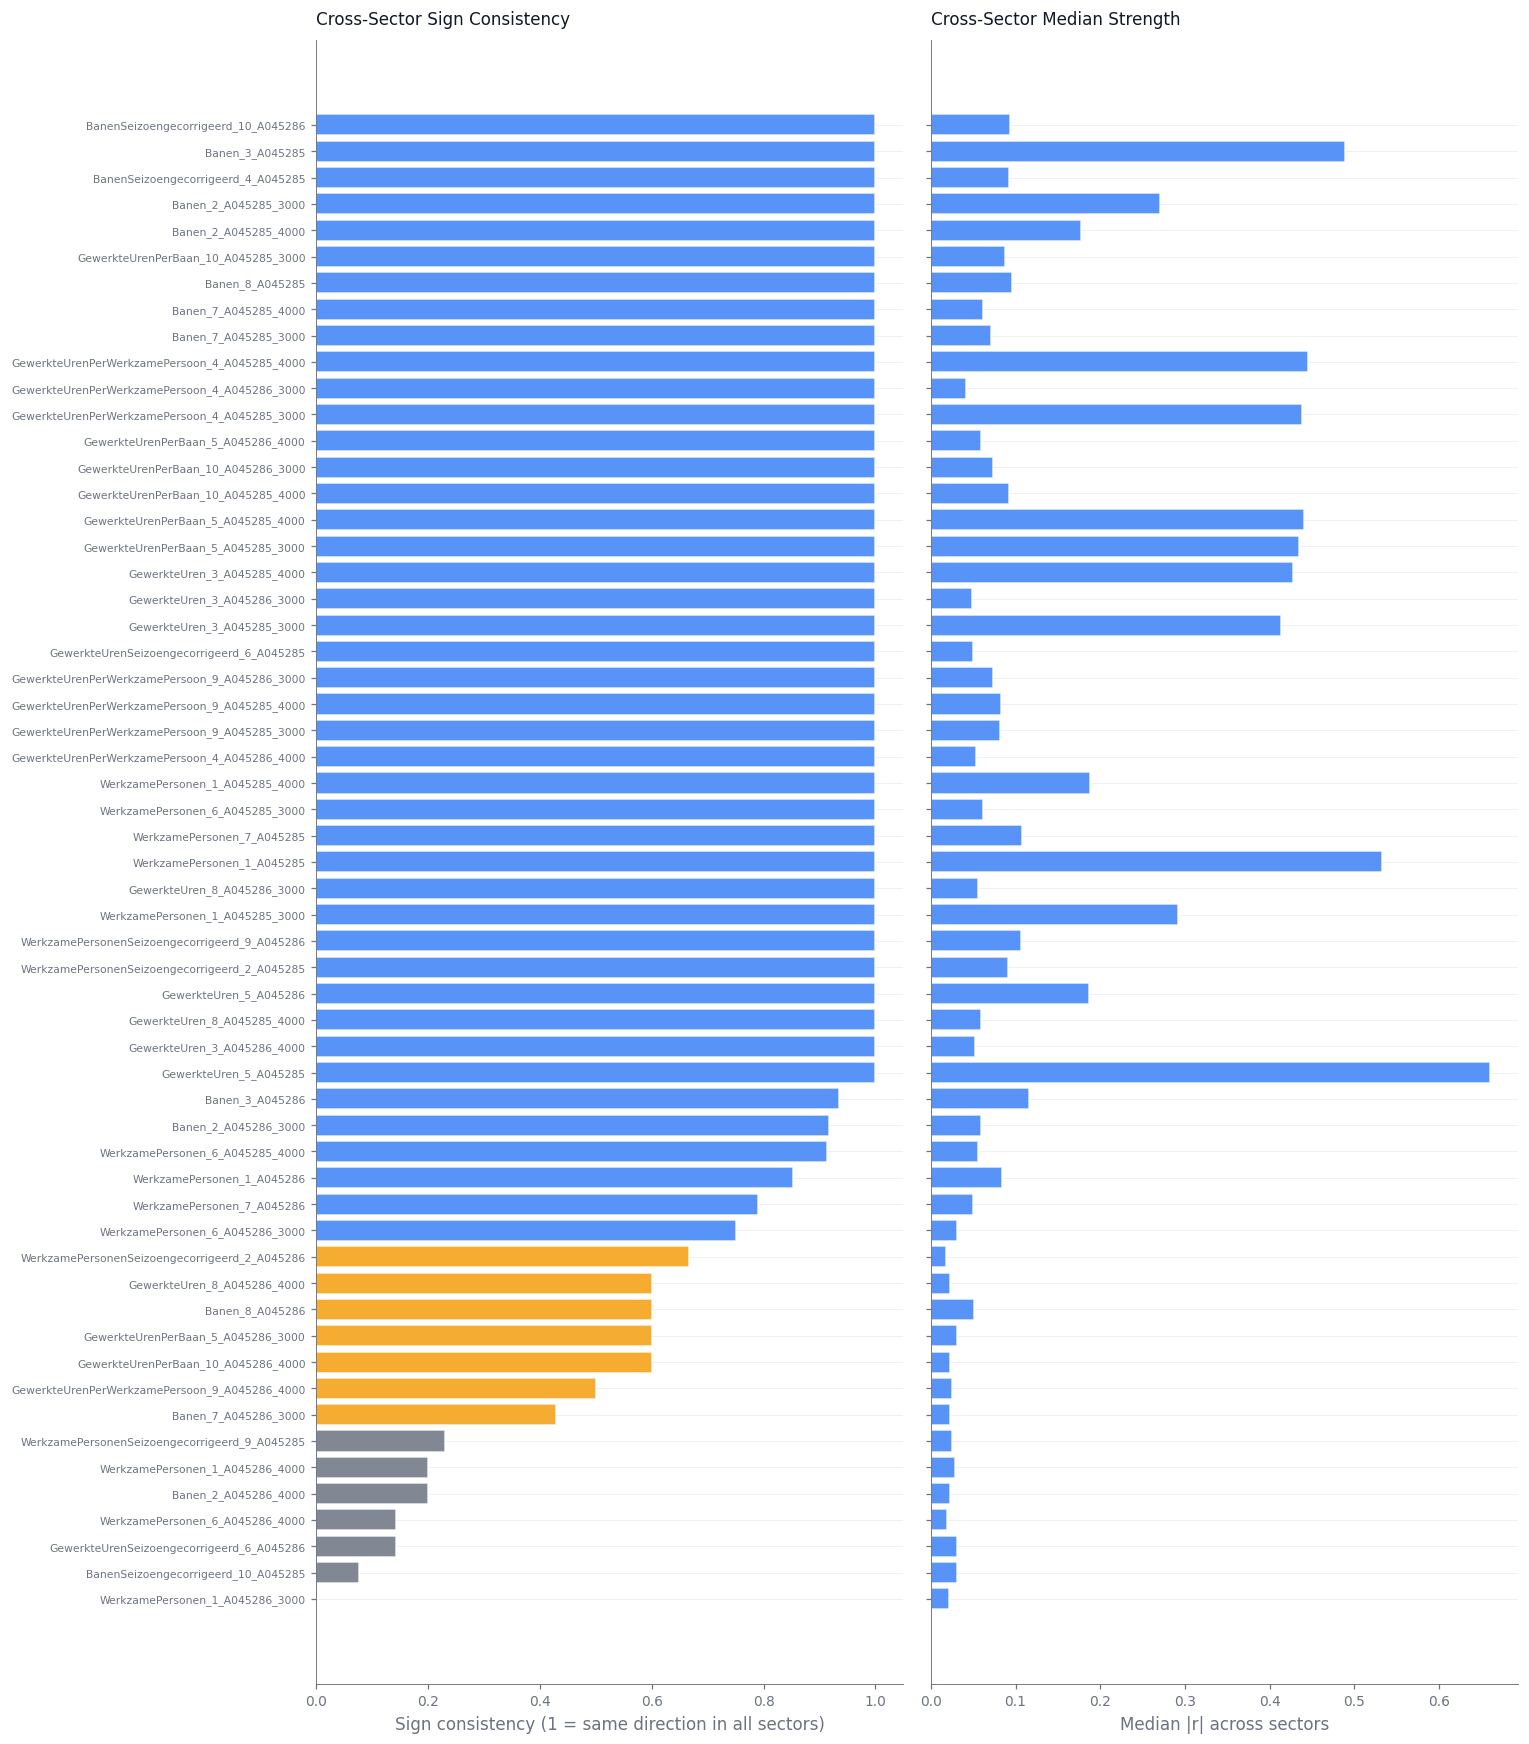

In [ ]:
# ── Visualise: sign consistency vs median |r| ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(stability) * 0.28)))

feats = stability.index.tolist()
y_pos = range(len(feats))

colors_sc = [RETAINED_COLOR if v >= 0.7 else ACCENT_COLOR if v >= 0.4 else DROPPED_COLOR
             for v in stability["sign_consistency"]]
axes[0].barh(y_pos, stability["sign_consistency"], color=colors_sc, edgecolor="white", alpha=0.85)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(feats, fontsize=7)
axes[0].set_xlabel("Sign consistency (1 = same direction in all sectors)")
axes[0].set_title("Cross-Sector Sign Consistency")
axes[0].invert_yaxis()
axes[0].set_xlim(0, 1.05)
sns.despine(ax=axes[0])

axes[1].barh(y_pos, stability["median_abs_r"], color=RETAINED_COLOR,
             edgecolor="white", alpha=0.85)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([], fontsize=7)
axes[1].set_xlabel("Median |r| across sectors")
axes[1].set_title("Cross-Sector Median Strength")
axes[1].invert_yaxis()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

### Interpreting the stability analysis

- **Sign consistency** (left): 1.0 = the feature moves in the same direction relative
  to absenteeism in all sectors. 0.0 = equally split positive and negative.
- **Median |r|** (right): strength of the typical correlation.

The ideal feature for a global model scores high on both. Features with **low sign
consistency but moderate median |r|** indicate genuine economic heterogeneity — e.g.,
more hours-per-worker might reduce absenteeism in income-driven sectors but increase
it in physically demanding ones. The per-sector models handle this through
sector-specific coefficients.

### Why per-sector feature selection is impractical

With ~119 quarterly observations per sector and ~60 features, per-sector selection
operates in a high-dimensional regime. A correlation of r=0.18 from n=119 has a 95%
confidence interval of roughly [0.00, 0.35] — you cannot distinguish signal from noise.
The current architecture handles this at a different layer: **global** selection
(4,641 rows) for statistical power, **per-sector** model training with regularisation
for sector adaptation.

---
## ✅ Done!

Your selected features are saved. The training pipeline picks them up via `model_configs.py`.

### Experimenting further
- **Change vote threshold:** set `VOTE_THRESHOLD` in Phase 3, re-run from there.
- **Disable a filter:** set any `APPLY_*` to `False`, re-run Phase 3 onward.
- **Change filter parameters:** adjust thresholds in Phase 2, re-run that cell + Phase 3 onward.
- **Save multiple presets:** change `PRESET_NAME`, re-run the export cell.
- **Additional filters** (importable but not in the main pipeline):
  - `apply_tree_filter()` — permutation importance from ExtraTrees. Excluded because in
    testing it passed 60/61 features with default settings (does not discriminate). Useful
    with a higher threshold (≥ 0.005) for exploratory analysis.
  - `apply_domain_prefix_filter()` — CBS table name allowlist for domain-knowledge-driven
    selection, bypassing statistics entirely.